# Benchmark Definitivo de MSI

## Pregunta central

> Si MSI dice que una molecula es "similar" a la referencia, **realmente tiene propiedades fisicoquimicas parecidas?**

Para responder esto, tomamos 5 datasets donde **conocemos las propiedades reales** de cada molecula. Luego comparamos:

- Las **top-N moleculas segun MSI** (menor theta)
- Las **top-N moleculas segun TSI** (mayor Tanimoto)
- Las **top-N moleculas segun Coseno** (mayor similitud coseno)

El metodo que seleccione moleculas con propiedades mas cercanas a la referencia **gana**.

---

### Datasets utilizados

| Dataset | Moleculas | Propiedad medida | Tipo |
|---------|-----------|------------------|------|
| QM9 | ~127,000 | E_gap, HOMO, LUMO, dipolo, polarizabilidad | Computacional (DFT) |
| **QM8** | **21,786** | **Energias de excitacion electronica (E1, E2), fuerzas de oscilador** | **Computacional (CC2, PBE0, CAM-B3LYP)** |
| ESOL | 1,128 | Solubilidad acuosa (logS) | Experimental |
| FreeSolv | 642 | Energia libre de hidratacion | Experimental |
| Lipophilicity | 4,200 | logD a pH 7.4 | Experimental |

**Hipotesis a probar:** MSI es especialmente fuerte para propiedades cuanticas/electronicas (QM9, QM8), donde la topologia molecular gobierna la estructura electronica.

---
## Seccion 0 — Imports y configuracion inicial

In [19]:
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

from gensim.models import Word2Vec
from msi import generate_2d_vectors, generate_300d_vectors, analyze_against_reference

sns.set_theme(style='white', font_scale=1.1)

In [20]:
# ---- Rutas ----
DATA_DIR       = 'data'
BENCHMARK_DIR  = os.path.join(DATA_DIR, 'benchmark')
OUTPUT_DIR     = 'output_benchmark'
MODEL_PATH     = os.path.join(DATA_DIR, 'model_300dim.pkl')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---- Parametros del benchmark ----
N_BOOT      = 10_000   # Iteraciones de bootstrap
RANDOM_SEED = 42

# ---- Cargar modelo mol2vec ----
print('Cargando modelo mol2vec...')
t0 = time.time()
model = Word2Vec.load(MODEL_PATH)
print(f'Modelo cargado en {time.time()-t0:.1f}s  (vocabulario: {len(model.wv):,} tokens, dimension: {model.wv.vector_size})')

2026-02-24 11:18:45,086 - INFO - loading Word2Vec object from data/model_300dim.pkl


Cargando modelo mol2vec...


2026-02-24 11:18:45,372 - INFO - loading wv recursively from data/model_300dim.pkl.wv.* with mmap=None
2026-02-24 11:18:45,374 - INFO - setting ignored attribute syn0norm to None
2026-02-24 11:18:45,439 - INFO - setting ignored attribute cum_table to None
2026-02-24 11:18:45,498 - INFO - Word2Vec lifecycle event {'fname': 'data/model_300dim.pkl', 'datetime': '2026-02-24T11:18:45.498482', 'gensim': '4.4.0', 'python': '3.13.5 (v3.13.5:6cb20a219a8, Jun 11 2025, 12:23:45) [Clang 16.0.0 (clang-1600.0.26.6)]', 'platform': 'macOS-15.5-arm64-arm-64bit-Mach-O', 'event': 'loaded'}


Modelo cargado en 0.4s  (vocabulario: 21,003 tokens, dimension: 300)


---
## Seccion 1 — Definir los datasets y sus moleculas de referencia

Cada entrada en la lista `BENCHMARK_DATASETS` define:

- **`filename`**: El CSV preparado por `prepare_benchmark.py`, con la molecula de referencia en la fila 0.
- **`properties`**: Las columnas del CSV que contienen propiedades medidas (lo que usamos para validar).
- **`n_values`**: Para cuantas moleculas top-N hacemos la comparacion. Ajustado al tamaño del dataset:
  - FreeSolv (642 mol): maximo N=50
  - ESOL / Lipophilicity: maximo N=100
  - QM8 (21k mol) / QM9 (127k mol): maximo N=250

In [21]:
BENCHMARK_DATASETS = [

    # ===== QM9: propiedades cuanticas (computacionales) =====
    {
        "name": "qm9_aniline",
        "filename": os.path.join(DATA_DIR, "qm9_anilin.csv"),
        "properties": {
            "gap":   ("$E_{gap}$", "$E_h$"),
            "homo":  ("HOMO", "$E_h$"),
            "lumo":  ("LUMO", "$E_h$"),
            "mu":    ("Dipolo $\mu$", "D"),
            "alpha": ("Polarizabilidad $\\alpha$", "$Bohr^3$"),
        },
        "dataset_label": "QM9",
        "reference_label": "Anilina",
        "n_values": [10, 25, 50, 100, 250],
    },
    {
        "name": "qm9_pyridine",
        "filename": os.path.join(BENCHMARK_DIR, "qm9_pyridine.csv"),
        "properties": {
            "gap":  ("$E_{gap}$", "$E_h$"),
            "homo": ("HOMO", "$E_h$"),
            "lumo": ("LUMO", "$E_h$"),
            "mu":   ("Dipolo $\mu$", "D"),
        },
        "dataset_label": "QM9",
        "reference_label": "Piridina",
        "n_values": [10, 25, 50, 100, 250],
    },

    # ===== QM8: espectros electronicos (computacionales) =====
    # Propiedades: energias de excitacion S0→S1 y S0→S2 calculadas con
    # 3 metodos (CC2, PBE0, CAM-B3LYP). CC2 es el mas preciso.
    {
        "name": "qm8_aniline",
        "filename": os.path.join(BENCHMARK_DIR, "qm8_aniline.csv"),
        "properties": {
            "E1-CC2": ("E1 excitacion (CC2)", "$E_h$"),
            "E2-CC2": ("E2 excitacion (CC2)", "$E_h$"),
            "E1-CAM": ("E1 excitacion (CAM)", "$E_h$"),
        },
        "dataset_label": "QM8",
        "reference_label": "Anilina",
        "n_values": [10, 25, 50, 100, 250],
    },
    {
        "name": "qm8_pyridine",
        "filename": os.path.join(BENCHMARK_DIR, "qm8_pyridine.csv"),
        "properties": {
            "E1-CC2": ("E1 excitacion (CC2)", "$E_h$"),
            "E2-CC2": ("E2 excitacion (CC2)", "$E_h$"),
            "E1-CAM": ("E1 excitacion (CAM)", "$E_h$"),
        },
        "dataset_label": "QM8",
        "reference_label": "Piridina",
        "n_values": [10, 25, 50, 100, 250],
    },
    {
        "name": "qm8_phenol",
        "filename": os.path.join(BENCHMARK_DIR, "qm8_phenol.csv"),
        "properties": {
            "E1-CC2": ("E1 excitacion (CC2)", "$E_h$"),
            "E2-CC2": ("E2 excitacion (CC2)", "$E_h$"),
            "E1-CAM": ("E1 excitacion (CAM)", "$E_h$"),
        },
        "dataset_label": "QM8",
        "reference_label": "Fenol",
        "n_values": [10, 25, 50, 100, 250],
    },

    # ===== ESOL: solubilidad acuosa (experimental) =====
    {
        "name": "esol_caffeine",
        "filename": os.path.join(BENCHMARK_DIR, "esol_caffeine.csv"),
        "properties": {"logS": ("Solubilidad (logS)", "log mol/L")},
        "dataset_label": "ESOL",
        "reference_label": "Cafeina",
        "n_values": [10, 25, 50, 100],
    },
    {
        "name": "esol_naphthalene",
        "filename": os.path.join(BENCHMARK_DIR, "esol_naphthalene.csv"),
        "properties": {"logS": ("Solubilidad (logS)", "log mol/L")},
        "dataset_label": "ESOL",
        "reference_label": "Naftaleno",
        "n_values": [10, 25, 50, 100],
    },

    # ===== FreeSolv: energia libre de hidratacion (experimental) =====
    {
        "name": "freesolv_toluene",
        "filename": os.path.join(BENCHMARK_DIR, "freesolv_toluene.csv"),
        "properties": {"hydration_free_energy": ("$\\Delta G_{hyd}$", "kcal/mol")},
        "dataset_label": "FreeSolv",
        "reference_label": "Tolueno",
        "n_values": [10, 25, 50],
    },
    {
        "name": "freesolv_ethanol",
        "filename": os.path.join(BENCHMARK_DIR, "freesolv_ethanol.csv"),
        "properties": {"hydration_free_energy": ("$\\Delta G_{hyd}$", "kcal/mol")},
        "dataset_label": "FreeSolv",
        "reference_label": "Etanol",
        "n_values": [10, 25, 50],
    },

    # ===== Lipophilicity: logD a pH 7.4 (experimental) =====
    {
        "name": "lipo_diclofenac",
        "filename": os.path.join(BENCHMARK_DIR, "lipo_diclofenac.csv"),
        "properties": {"logD": ("logD (pH 7.4)", "")},
        "dataset_label": "Lipophilicity",
        "reference_label": "Diclofenac",
        "n_values": [10, 25, 50, 100],
    },
    {
        "name": "lipo_naproxen",
        "filename": os.path.join(BENCHMARK_DIR, "lipo_naproxen.csv"),
        "properties": {"logD": ("logD (pH 7.4)", "")},
        "dataset_label": "Lipophilicity",
        "reference_label": "Naproxeno",
        "n_values": [10, 25, 50, 100],
    },
]

# Resumen de la configuracion
print(f'{len(BENCHMARK_DATASETS)} corridas configuradas:\n')
for ds in BENCHMARK_DATASETS:
    props = list(ds['properties'].keys())
    print(f'  {ds["dataset_label"]:>14s} / {ds["reference_label"]:<14s}  '
          f'propiedades: {props},  N: {ds["n_values"]}')

11 corridas configuradas:

             QM9 / Anilina         propiedades: ['gap', 'homo', 'lumo', 'mu', 'alpha'],  N: [10, 25, 50, 100, 250]
             QM9 / Piridina        propiedades: ['gap', 'homo', 'lumo', 'mu'],  N: [10, 25, 50, 100, 250]
             QM8 / Anilina         propiedades: ['E1-CC2', 'E2-CC2', 'E1-CAM'],  N: [10, 25, 50, 100, 250]
             QM8 / Piridina        propiedades: ['E1-CC2', 'E2-CC2', 'E1-CAM'],  N: [10, 25, 50, 100, 250]
             QM8 / Fenol           propiedades: ['E1-CC2', 'E2-CC2', 'E1-CAM'],  N: [10, 25, 50, 100, 250]
            ESOL / Cafeina         propiedades: ['logS'],  N: [10, 25, 50, 100]
            ESOL / Naftaleno       propiedades: ['logS'],  N: [10, 25, 50, 100]
        FreeSolv / Tolueno         propiedades: ['hydration_free_energy'],  N: [10, 25, 50]
        FreeSolv / Etanol          propiedades: ['hydration_free_energy'],  N: [10, 25, 50]
   Lipophilicity / Diclofenac      propiedades: ['logD'],  N: [10, 25, 50, 100]
   Lipo

---
## Seccion 2 — Ejecutar el pipeline MSI en cada dataset

Para cada par (dataset, referencia) ejecutamos los 3 pasos del pipeline MSI:

1. **`generate_2d_vectors`** — Convierte SMILES a vectores mol2vec y los proyecta a 2D (PCA).
   Usamos `preserve_columns=True` para que las columnas de propiedades (logS, logD, etc.) sobrevivan.
2. **`generate_300d_vectors`** — Genera los embeddings completos de 300 dimensiones.
3. **`analyze_against_reference`** — Calcula theta (MSI), Tanimoto (TSI), coseno, y distancia de Mahalanobis.

Al terminar, cada molecula tiene:
- `theta` → angulo de Mahalanobis (MSI: **menor = mas similar**)
- `tanimoto_similarity` → Tanimoto sobre Morgan fingerprints (TSI: **mayor = mas similar**)
- `embedding_similarity` → coseno en espacio 300D (**mayor = mas similar**)
- Las columnas originales de propiedades (logS, logD, gap, etc.)

In [22]:
def run_full_pipeline(name, filepath, description):
    """Ejecuta el pipeline MSI completo para un dataset."""
    print(f'\n{"=" * 70}')
    print(f'  {description}')
    print(f'  Archivo: {filepath}')
    print(f'{"=" * 70}')

    t0 = time.time()

    # Paso 1: Vectores 2D (PCA de mol2vec)
    print(f'  [1/3] Vectores 2D...')
    path_2d = generate_2d_vectors(
        path=filepath, model=model, output_dir=OUTPUT_DIR, preserve_columns=True,
    )

    # Paso 2: Vectores 300D (embeddings completos)
    print(f'  [2/3] Vectores 300D...')
    path_300d = generate_300d_vectors(
        path=filepath, model=model, output_dir=OUTPUT_DIR,
    )

    # Paso 3: Analisis de similitud (theta, Tanimoto, coseno, Mahalanobis)
    print(f'  [3/3] Analisis de similitud...')
    results_df, metrics = analyze_against_reference(
        path_2d=path_2d, path_300d=path_300d, output_dir=OUTPUT_DIR,
    )

    elapsed = time.time() - t0
    print(f'  Listo: {len(results_df):,} moleculas en {elapsed:.1f}s')
    return results_df, metrics

In [23]:
# Ejecutar los 11 pipelines (2 QM9 + 3 QM8 + 2 ESOL + 2 FreeSolv + 2 Lipo)
results = {}
total_t0 = time.time()

for ds in BENCHMARK_DATASETS:
    desc = f'{ds["dataset_label"]} — ref: {ds["reference_label"]}'
    df, metrics = run_full_pipeline(ds['name'], ds['filename'], desc)
    results[ds['name']] = {'df': df, 'metrics': metrics, 'config': ds}

    # Verificar que las columnas de propiedades estan en el resultado
    for prop_col in ds['properties']:
        if prop_col in df.columns:
            ref_val = df[prop_col].iloc[0]
            print(f'    ✓ Propiedad "{prop_col}" encontrada. Valor de referencia: {ref_val}')
        else:
            print(f'    ✗ ADVERTENCIA: "{prop_col}" NO encontrada en columnas: {list(df.columns)}')

print(f'\n{"=" * 70}')
print(f'  TODOS LOS PIPELINES COMPLETADOS — {len(results)} datasets en {time.time()-total_t0:.1f}s')
print(f'{"=" * 70}')


  QM9 — ref: Anilina
  Archivo: data/qm9_anilin.csv
  [1/3] Vectores 2D...


2026-02-24 11:18:45,891 - INFO - Dataset size: 133885 molecules
100%|████████████████████████████████| 133885/133885 [00:03<00:00, 36376.86it/s]
2026-02-24 11:18:52,592 - INFO - After filtering: 127537 molecules (removed 0 invalid SMILES, 6348 with unknown identifiers)
2026-02-24 11:19:01,708 - INFO - 2D vectors saved to output_benchmark/qm9_anilin_2d_vectors.csv
2026-02-24 11:19:01,717 - INFO - === PIPELINE METRICS SUMMARY ===
2026-02-24 11:19:01,717 - INFO -   invalid_smiles: 0
2026-02-24 11:19:01,717 - INFO -   unknown_identifiers: 6348
2026-02-24 11:19:01,718 - INFO -   covariance_condition_number: None
2026-02-24 11:19:01,718 - INFO -   tanimoto_range: (None, None)
2026-02-24 11:19:01,718 - INFO -   mahalanobis_stats: {}
2026-02-24 11:19:01,718 - INFO -   runtime: {}
2026-02-24 11:19:02,478 - INFO - Dataset size: 133885 molecules


  [2/3] Vectores 300D...


100%|████████████████████████████████| 133885/133885 [00:03<00:00, 40285.44it/s]
2026-02-24 11:19:08,589 - INFO - After filtering: 127537 molecules (removed 0 invalid SMILES, 6348 with unknown identifiers)
2026-02-24 11:19:25,413 - INFO - 300D vectors saved to output_benchmark/qm9_anilin_300d_vectors.csv


  [3/3] Analisis de similitud...


...

  [2/3] Vectores 300D...


100%|████████████████████████████████████| 4200/4200 [00:00<00:00, 15342.19it/s]
2026-02-24 11:21:14,639 - INFO - After filtering: 4195 molecules (removed 0 invalid SMILES, 5 with unknown identifiers)
2026-02-24 11:21:15,317 - INFO - 300D vectors saved to output_benchmark/lipo_naproxen_300d_vectors.csv


  [3/3] Analisis de similitud...


2026-02-24 11:21:15,863 - INFO - Covariance matrix condition number: 4.88e+03
2026-02-24 11:21:16,047 - INFO - Results saved to output_benchmark/lipo_naproxen_2d_vectors_against_it.csv
2026-02-24 11:21:16,047 - INFO - === PIPELINE METRICS SUMMARY ===
2026-02-24 11:21:16,047 - INFO -   invalid_smiles: 0
2026-02-24 11:21:16,048 - INFO -   unknown_identifiers: 0
2026-02-24 11:21:16,048 - INFO -   covariance_condition_number: 4875.744570223601
2026-02-24 11:21:16,048 - INFO -   tanimoto_range: (0.0, 1.0)
2026-02-24 11:21:16,048 - INFO -   mahalanobis_stats: {'nobs': 4195, 'mean': 21.888833957432695, 'variance': 19.050006241292948, 'min': 0.0, 'max': 61.55393646457386}
2026-02-24 11:21:16,049 - INFO -   runtime: {'data_loading': 0.19385719299316406, 'weight_calculation': 0.29932117462158203, 'covariance_calculation': 0.018788814544677734, 'mahalanobis_calculation': 0.010323286056518555, 'tanimoto_calculation': 0.09016609191894531, 'angle_calculation': 0.01209115982055664, 'data_saving': 0.0

  Listo: 4,195 moleculas en 7.3s
    ✓ Propiedad "logD" encontrada. Valor de referencia: 0.23

  TODOS LOS PIPELINES COMPLETADOS — 11 datasets en 150.4s


---
## Seccion 3 — La prueba central: Proximidad de propiedades

### La logica es simple:

1. Tomamos las **N moleculas mas similares** segun cada metodo (MSI, TSI, Coseno).
2. Medimos **que tan lejos** estan sus propiedades de la molecula de referencia.
3. El metodo cuyas moleculas "similares" tengan **propiedades mas cercanas** gana.

### Ejemplo concreto

Supongamos que la cafeina tiene logS = -0.55:

- Las 10 moleculas mas similares segun **MSI** tienen logS promedio de -0.90 → desviacion = 0.35
- Las 10 moleculas mas similares segun **TSI** tienen logS promedio de -1.80 → desviacion = 1.25
- Las 10 moleculas mas similares segun **Coseno** tienen logS promedio de -1.50 → desviacion = 0.95

**MSI gana** porque sus analogos tienen solubilidad mas parecida a la cafeina.

### Metricas calculadas

| Metrica | Formula | Interpretacion |
|---------|---------|----------------|
| `MSI_dev` | mean(abs(propiedad_topN - propiedad_ref)) | Desviacion absoluta media. **Menor = mejor.** |
| `MSI_norm` | MSI_dev / Random_dev | Fraccion vs azar. **< 1.0 = mejor que aleatorio.** |
| `ratio_tsi_msi` | TSI_dev / MSI_dev | **> 1.0 = MSI mejor que TSI.** |
| `p_msi` | % de bootstrap ≤ MSI_dev | **< 0.05 = estadisticamente significativo.** |

In [24]:
np.random.seed(RANDOM_SEED)

all_results = []  # Aqui se acumulan TODOS los tests

for ds_name, r in results.items():
    df     = r['df']
    config = r['config']
    cands  = df.iloc[1:].copy()  # Todo excepto la referencia (fila 0)

    ds_label  = config['dataset_label']
    ref_label = config['reference_label']

    for prop_col, (prop_label, prop_unit) in config['properties'].items():
        if prop_col not in df.columns:
            print(f'  SKIP: {prop_col} no encontrada en {ds_name}')
            continue

        # Valor de la propiedad en la molecula de referencia
        ref_val = df[prop_col].iloc[0]

        # Baseline aleatorio: desviacion media de TODAS las moleculas
        random_dev = np.abs(cands[prop_col] - ref_val).mean()

        for N in config['n_values']:
            if N >= len(cands):
                continue

            # --- Top-N por cada metodo ---
            top_msi = cands.nsmallest(N, 'theta')                # MSI: menor theta = mas similar
            top_tsi = cands.nlargest(N, 'tanimoto_similarity')   # TSI: mayor Tanimoto = mas similar
            top_cos = cands.nlargest(N, 'embedding_similarity')  # Coseno: mayor coseno = mas similar

            # --- Desviacion media de cada metodo ---
            msi_dev = np.abs(top_msi[prop_col] - ref_val).mean()
            tsi_dev = np.abs(top_tsi[prop_col] - ref_val).mean()
            cos_dev = np.abs(top_cos[prop_col] - ref_val).mean()

            # --- Bootstrap: solo para N <= 25 (por tiempo de computo) ---
            # Pregunta: "si eligiera N moleculas al azar, que tan seguido
            #            obtendria una desviacion tan baja como MSI?"
            p_msi, p_tsi, p_cos = np.nan, np.nan, np.nan
            if N <= 25:
                boot_devs = np.zeros(N_BOOT)
                for b in range(N_BOOT):
                    idx = np.random.choice(len(cands), size=N, replace=False)
                    boot_devs[b] = np.abs(cands[prop_col].iloc[idx].values - ref_val).mean()
                p_msi = (boot_devs <= msi_dev).mean()
                p_tsi = (boot_devs <= tsi_dev).mean()
                p_cos = (boot_devs <= cos_dev).mean()

            # --- Quien gana este test? ---
            devs   = {'MSI': msi_dev, 'TSI': tsi_dev, 'Cosine': cos_dev}
            winner = min(devs, key=devs.get)

            all_results.append({
                'dataset': ds_label, 'reference': ref_label, 'ds_name': ds_name,
                'property': prop_label, 'prop_col': prop_col, 'unit': prop_unit,
                'N': N, 'n_molecules': len(cands),
                'ref_value': ref_val,
                'MSI_dev': msi_dev, 'TSI_dev': tsi_dev, 'Cos_dev': cos_dev,
                'Random_dev': random_dev,
                'MSI_norm':  msi_dev / random_dev if random_dev > 0 else np.nan,
                'TSI_norm':  tsi_dev / random_dev if random_dev > 0 else np.nan,
                'Cos_norm':  cos_dev / random_dev if random_dev > 0 else np.nan,
                'ratio_tsi_msi': tsi_dev / msi_dev if msi_dev > 0 else np.nan,
                'ratio_cos_msi': cos_dev / msi_dev if msi_dev > 0 else np.nan,
                'p_msi': p_msi, 'p_tsi': p_tsi, 'p_cos': p_cos,
                'winner': winner,
            })

bench_df = pd.DataFrame(all_results)
print(f'Tests totales: {len(bench_df)}')
print(f'Pares (dataset, referencia) unicos: {bench_df.groupby(["dataset", "reference"]).ngroups}')
print(f'Propiedades evaluadas: {bench_df["property"].nunique()}')

Tests totales: 112
Pares (dataset, referencia) unicos: 11
Propiedades evaluadas: 11


Veamos las primeras filas de resultados para verificar que todo se calculo correctamente:

In [25]:
# Mostrar los primeros resultados con las columnas mas importantes
cols_preview = ['dataset', 'reference', 'property', 'N',
                'MSI_dev', 'TSI_dev', 'Cos_dev',
                'ratio_tsi_msi', 'winner', 'p_msi']
display(bench_df[cols_preview].head(15).round(4))

,dataset,reference,property,N,MSI_dev,TSI_dev,Cos_dev,ratio_tsi_msi,winner,p_msi
0,QM9,Anilina,$E_{gap}$,10,0.0134,0.0261,0.0236,1.9543,MSI,0.0000
1,QM9,Anilina,$E_{gap}$,25,0.0116,0.0215,0.0172,1.8493,MSI,0.0000
2,QM9,Anilina,$E_{gap}$,50,0.0170,0.0211,0.0241,1.2401,MSI,NaN
3,QM9,Anilina,$E_{gap}$,100,0.0199,0.0207,0.0229,1.0417,MSI,NaN
4,QM9,Anilina,$E_{gap}$,250,0.0189,0.0221,0.0219,1.1679,MSI,NaN
5,QM9,Anilina,HOMO,10,0.0232,0.0113,0.0075,0.4860,Cosine,0.0009
6,QM9,Anilina,HOMO,25,0.0229,0.0149,0.0115,0.6519,Cosine,0.0000
7,QM9,Anilina,HOMO,50,0.0197,0.0154,0.0170,0.7850,TSI,NaN
8,QM9,Anilina,HOMO,100,0.0237,0.0197,0.0169,0.8322,Cosine,NaN
9,QM9,Anilina,HOMO,250,0.0263,0.0187,0.0199,0.7128,TSI,NaN


---
## Seccion 4 — Scorecard global: Quien gana?

Contamos cuantos tests gana cada metodo. Un "test" es una combinacion unica de (dataset, referencia, propiedad, N).

In [26]:
wins = bench_df['winner'].value_counts()

print('=' * 60)
print('  SCORECARD GLOBAL — Victorias por metodo')
print('=' * 60)
for method in ['MSI', 'TSI', 'Cosine']:
    n_wins = wins.get(method, 0)
    pct = 100 * n_wins / len(bench_df)
    print(f'  {method:>8s}: {n_wins:>3d} victorias  ({pct:.1f}%)')
print(f'{"":>8s}  {"─" * 25}')
print(f'  {"Total":>8s}: {len(bench_df):>3d} tests')
print('=' * 60)

  SCORECARD GLOBAL — Victorias por metodo
       MSI:  48 victorias  (42.9%)
       TSI:  23 victorias  (20.5%)
    Cosine:  41 victorias  (36.6%)
          ─────────────────────────
     Total: 112 tests


### Desglose: Victorias por dataset

Esto muestra si MSI domina en todos los tipos de datos o solo en algunos:

In [27]:
pivot_ds = bench_df.groupby(['dataset', 'winner']).size().unstack(fill_value=0)
for m in ['MSI', 'TSI', 'Cosine']:
    if m not in pivot_ds.columns:
        pivot_ds[m] = 0

print('Victorias por dataset:')
display(pivot_ds[['MSI', 'TSI', 'Cosine']])

Victorias por dataset:


winner,MSI,TSI,Cosine
dataset,,,
ESOL,4,3,1
FreeSolv,0,2,4
Lipophilicity,0,4,4
QM8,15,9,21
QM9,29,5,11


### Desglose: Victorias por tamaño de seleccion (N)

Esto muestra si la ventaja de MSI se mantiene al seleccionar mas moleculas:

In [28]:
pivot_n = bench_df.groupby(['N', 'winner']).size().unstack(fill_value=0)
for m in ['MSI', 'TSI', 'Cosine']:
    if m not in pivot_n.columns:
        pivot_n[m] = 0

print('Victorias por N:')
display(pivot_n[['MSI', 'TSI', 'Cosine']])

Victorias por N:


winner,MSI,TSI,Cosine
N,,,
10,6,1,17
25,11,9,4
50,16,4,4
100,9,3,10
250,6,6,6


---
## Seccion 5 — Visualizaciones globales

### Grafica 1: Barras de victorias totales

El metodo con la barra mas alta es el ganador global.

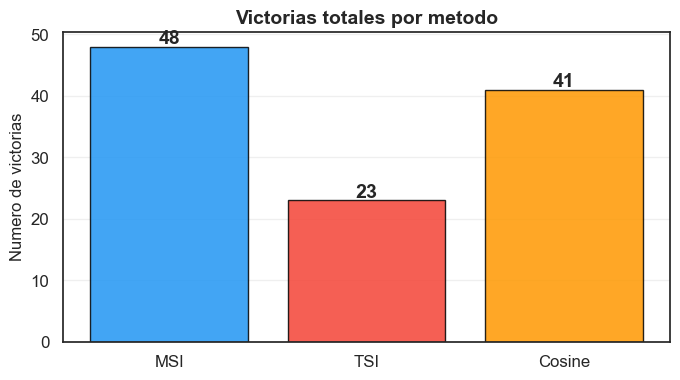

In [29]:
colores = {'MSI': '#2196F3', 'TSI': '#F44336', 'Cosine': '#FF9800'}
metodos = ['MSI', 'TSI', 'Cosine']

fig, ax = plt.subplots(figsize=(7, 4))
conteos = [wins.get(m, 0) for m in metodos]
bars = ax.bar(metodos, conteos, color=[colores[m] for m in metodos],
              alpha=0.85, edgecolor='black')

# Poner el numero encima de cada barra
for bar, val in zip(bars, conteos):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}', ha='center', fontsize=14, fontweight='bold')

ax.set_ylabel('Numero de victorias', fontsize=12)
ax.set_title('Victorias totales por metodo', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Grafica 2: Desviacion normalizada promedio

Cada barra muestra: `desviacion_del_metodo / desviacion_aleatoria`.

- Si la barra esta **por debajo de la linea gris (1.0)** → el metodo es mejor que elegir moleculas al azar.
- **Mas abajo = mejor.** El metodo ideal tendria una barra cercana a 0.

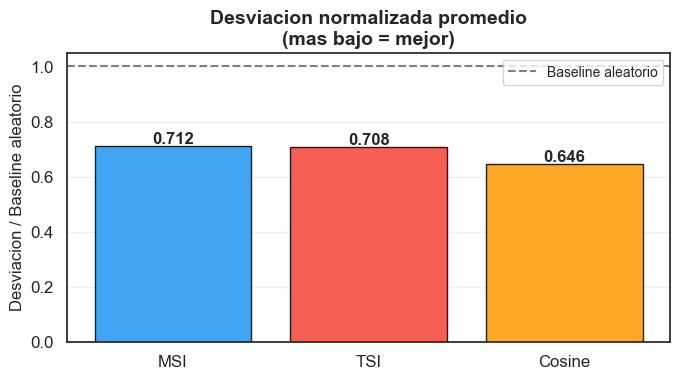

In [30]:
fig, ax = plt.subplots(figsize=(7, 4))

mean_norms = [
    bench_df['MSI_norm'].mean(),
    bench_df['TSI_norm'].mean(),
    bench_df['Cos_norm'].mean(),
]
bars = ax.bar(metodos, mean_norms, color=[colores[m] for m in metodos],
              alpha=0.85, edgecolor='black')

# Linea del baseline aleatorio
ax.axhline(y=1.0, color='gray', linestyle='--', lw=1.5, label='Baseline aleatorio')

# Valores encima de las barras
for bar, val in zip(bars, mean_norms):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('Desviacion / Baseline aleatorio', fontsize=12)
ax.set_title('Desviacion normalizada promedio\n(mas bajo = mejor)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Grafica 3: Ventaja MSI por dataset (ratio TSI/MSI)

Cada barra muestra cuantas veces **peor** es TSI comparado con MSI, promediado sobre todos los tests de ese dataset.

- **Barra > 1.0** → MSI es mejor que TSI en ese dataset.
- **Barra = 1.0** → empate.
- **Barra < 1.0** → TSI es mejor.

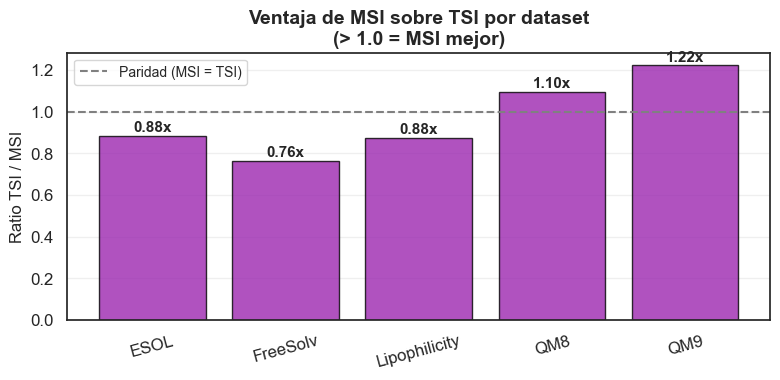

In [31]:
fig, ax = plt.subplots(figsize=(8, 4))

ratio_por_ds = bench_df.groupby('dataset')['ratio_tsi_msi'].mean()
nombres_ds = ratio_por_ds.index.tolist()

bars = ax.bar(nombres_ds, ratio_por_ds.values, color='#9C27B0', alpha=0.8, edgecolor='black')
ax.axhline(y=1.0, color='gray', linestyle='--', lw=1.5, label='Paridad (MSI = TSI)')

for bar, val in zip(bars, ratio_por_ds.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}x', ha='center', fontsize=11, fontweight='bold')

ax.set_ylabel('Ratio TSI / MSI', fontsize=12)
ax.set_title('Ventaja de MSI sobre TSI por dataset\n(> 1.0 = MSI mejor)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

---
## Seccion 6 — Escalamiento: Como cambia la ventaja al variar N?

Para cada par (dataset, referencia), comparamos la desviacion normalizada de los 3 metodos
a distintos valores de N. Las barras deben estar **por debajo de la linea gris (1.0)** para ser
mejores que el azar. Si MSI (azul) esta consistentemente mas abajo, su ventaja es robusta.

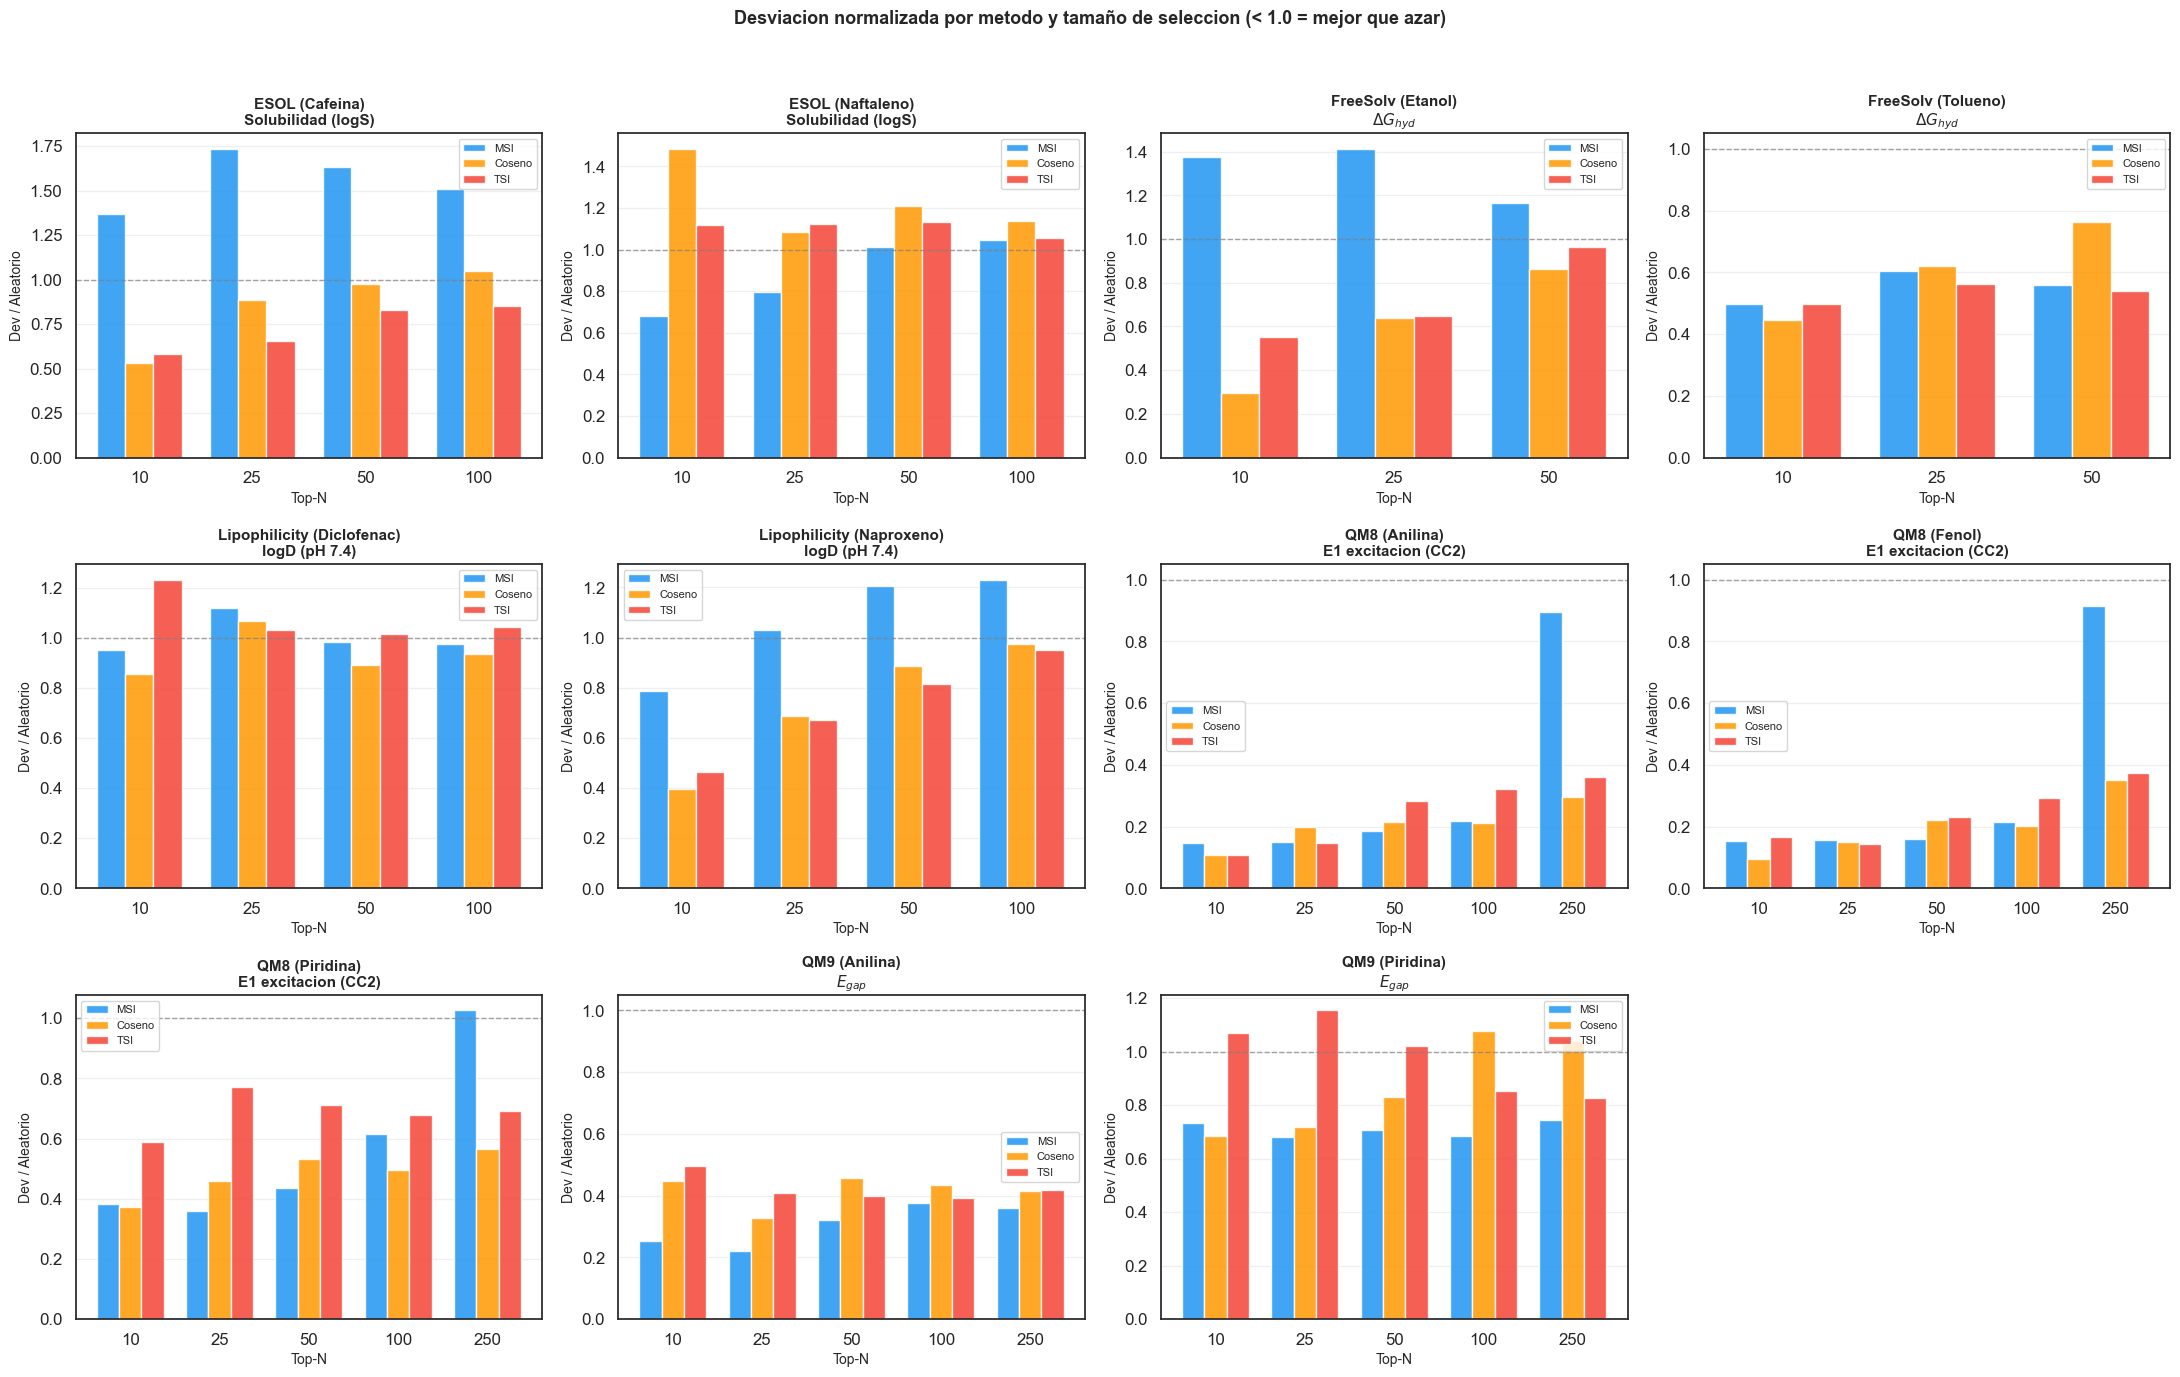

In [32]:
# Una subgrafica por cada par (dataset, referencia)
unique_runs = bench_df.groupby(['ds_name']).first().reset_index()
n_runs = len(unique_runs)

ncols = min(4, n_runs)
nrows = (n_runs + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.5 * nrows))
axes = axes.flatten()

for i, (_, run) in enumerate(unique_runs.iterrows()):
    ds_name   = run['ds_name']
    ds_label  = run['dataset']
    ref_label = run['reference']

    # Filtrar solo la primera propiedad de este dataset
    sub = bench_df[bench_df['ds_name'] == ds_name].copy()
    prop_col   = sub['prop_col'].iloc[0]
    prop_label = sub['property'].iloc[0]
    sub = sub[sub['prop_col'] == prop_col]

    ax = axes[i]
    n_vals = sub['N'].values
    x = np.arange(len(n_vals))
    w = 0.25

    # Barras agrupadas: MSI (azul), Coseno (naranja), TSI (rojo)
    ax.bar(x - w, sub['MSI_norm'].values, w, color='#2196F3', alpha=0.85, label='MSI')
    ax.bar(x,     sub['Cos_norm'].values, w, color='#FF9800', alpha=0.85, label='Coseno')
    ax.bar(x + w, sub['TSI_norm'].values, w, color='#F44336', alpha=0.85, label='TSI')
    ax.axhline(y=1.0, color='gray', linestyle='--', lw=1, alpha=0.7)

    ax.set_xticks(x)
    ax.set_xticklabels([str(n) for n in n_vals])
    ax.set_xlabel('Top-N', fontsize=10)
    ax.set_ylabel('Dev / Aleatorio', fontsize=10)
    ax.set_title(f'{ds_label} ({ref_label})\n{prop_label}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

# Ocultar ejes sobrantes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Desviacion normalizada por metodo y tamaño de seleccion (< 1.0 = mejor que azar)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Seccion 7 — Significancia estadistica (Bootstrap)

Para los tests con N=10, mostramos la distribucion de 10,000 muestras aleatorias (histograma gris).
Las lineas verticales marcan la desviacion observada de cada metodo:

- **Linea azul (MSI)**: Si esta en el extremo izquierdo del histograma → MSI es mucho mejor que el azar.
- **Linea roja (TSI)**: Si esta mas a la derecha que MSI → TSI selecciona analogos peores.
- **p-value**: Fraccion de muestras aleatorias con desviacion ≤ la observada. Si p < 0.05, es significativo.

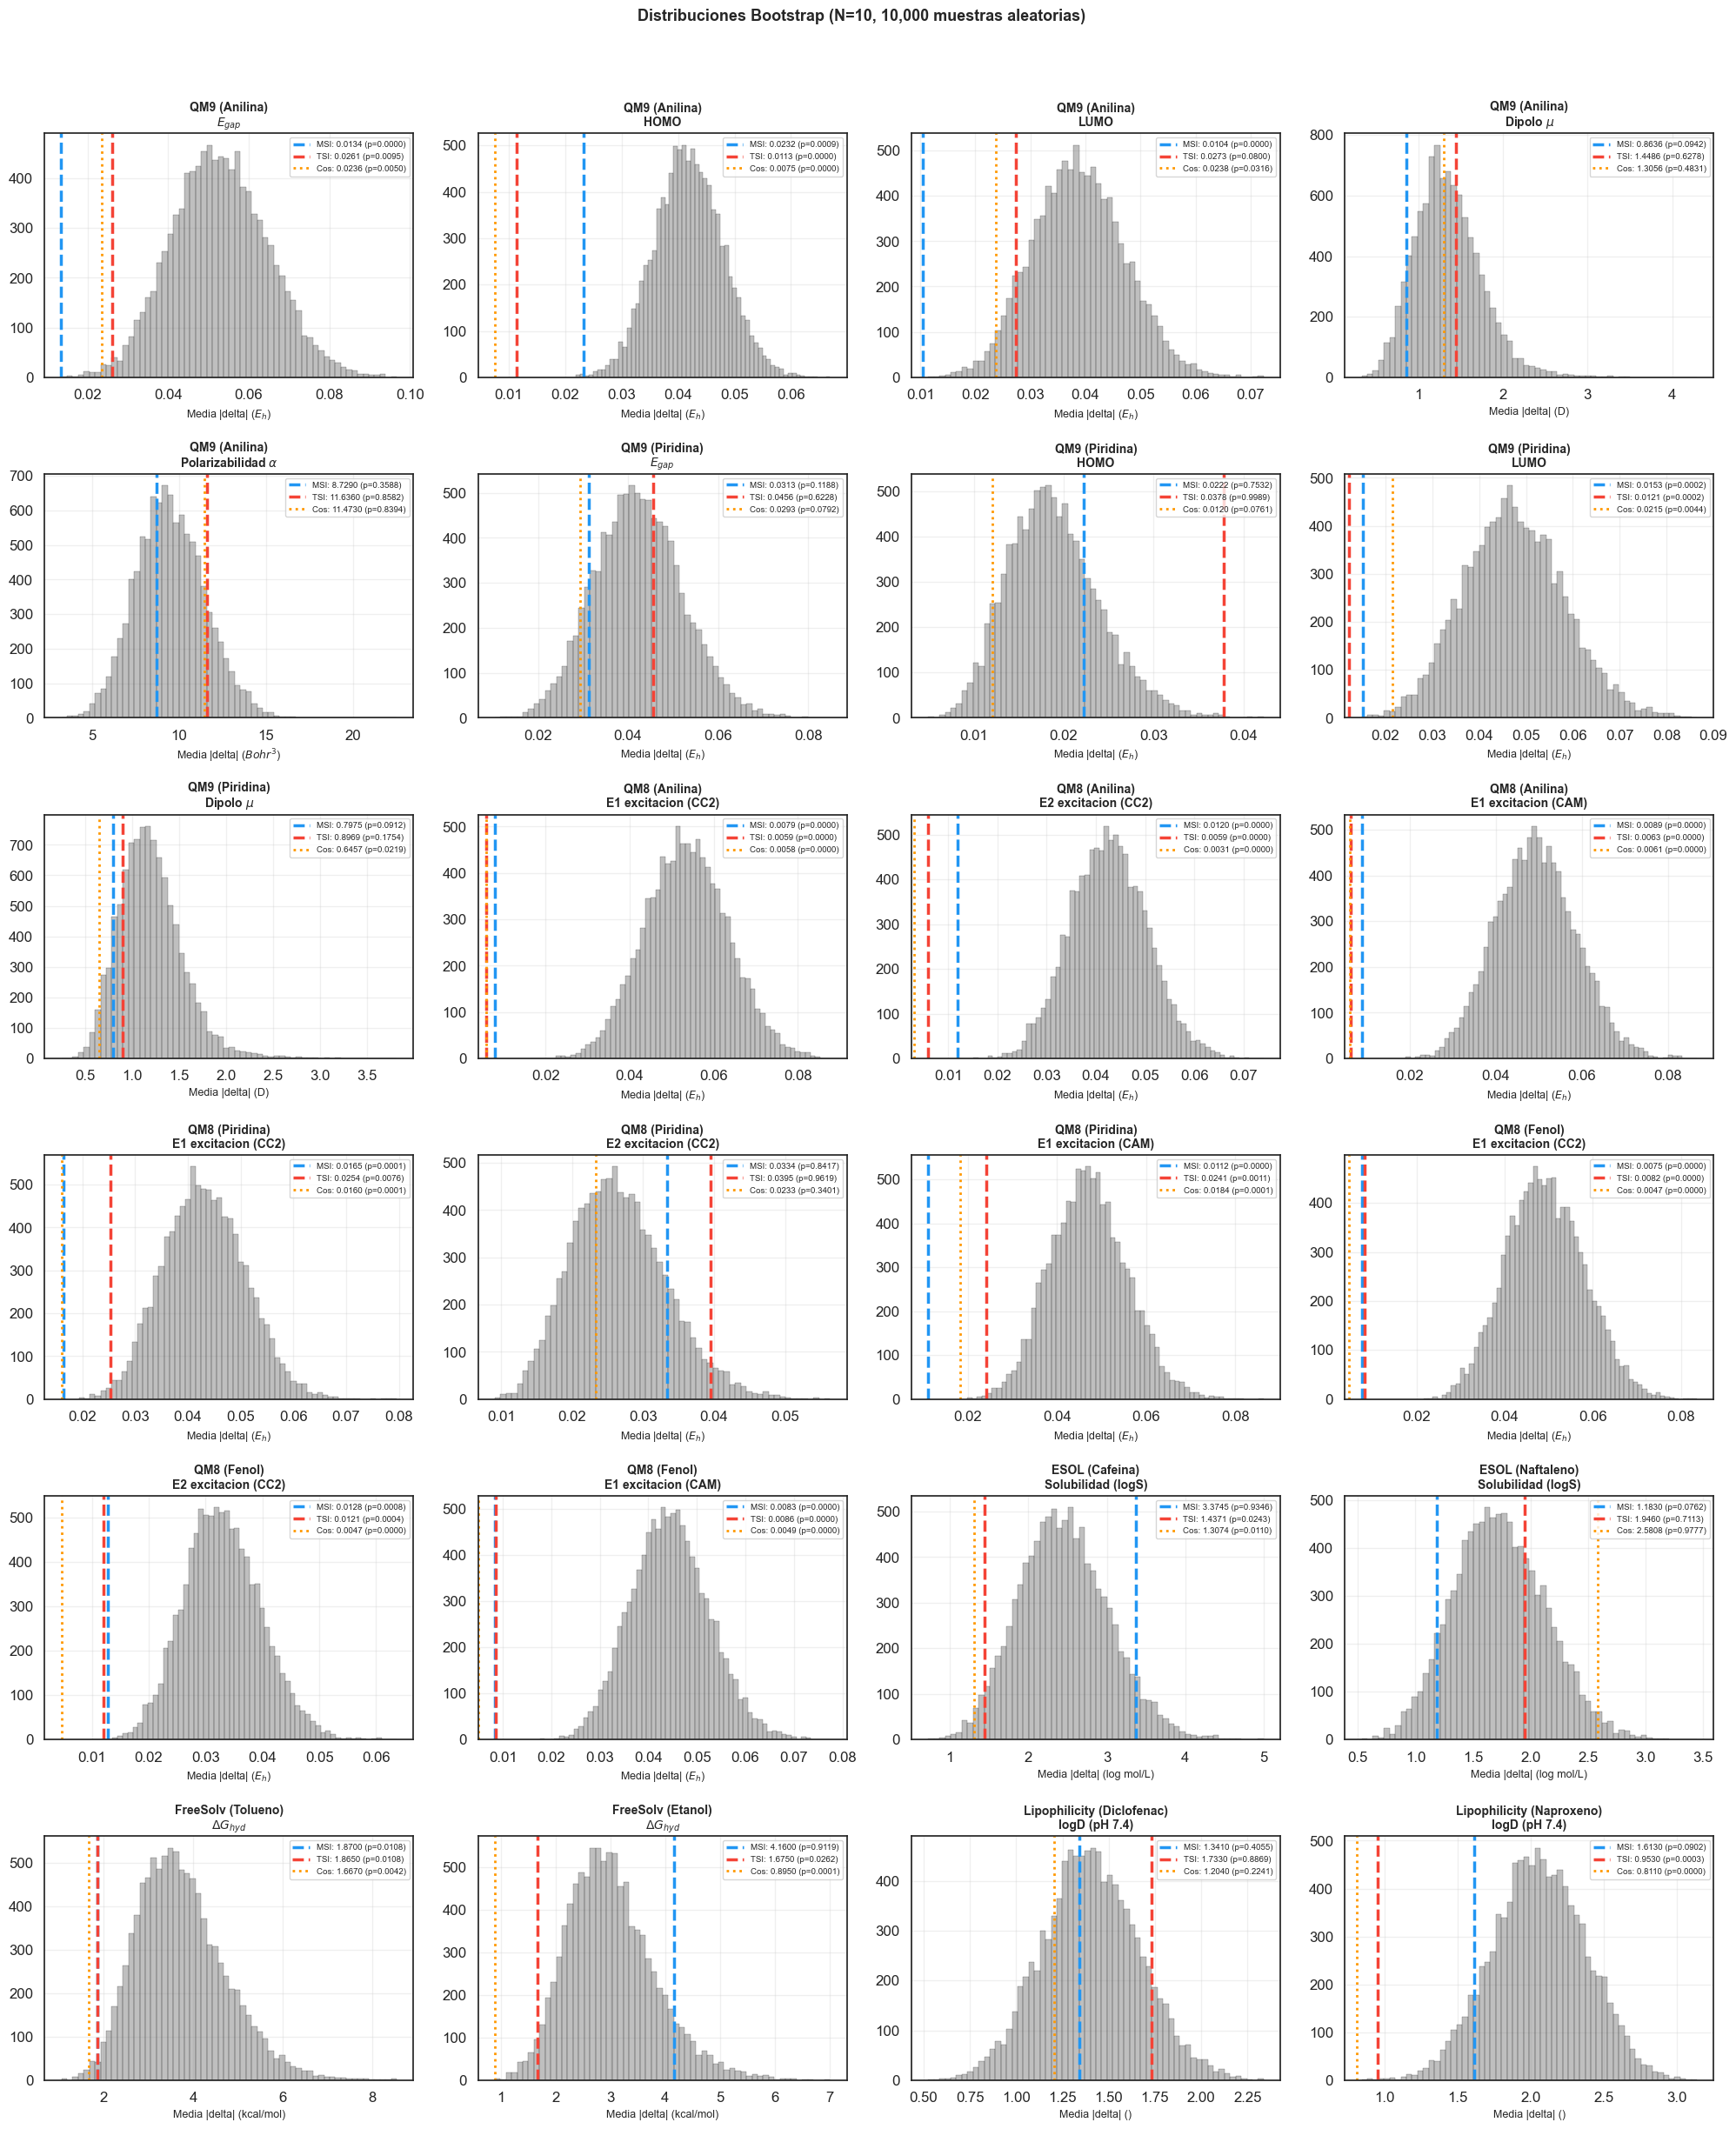

In [33]:
boot_tests = bench_df[(bench_df['N'] == 10) & (bench_df['p_msi'].notna())].copy()

if len(boot_tests) > 0:
    n_tests = len(boot_tests)
    ncols = min(4, n_tests)
    nrows = (n_tests + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    if n_tests == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    np.random.seed(RANDOM_SEED)

    for idx, (_, test) in enumerate(boot_tests.iterrows()):
        ax = axes[idx]

        # Regenerar bootstrap para este test
        ds_name  = test['ds_name']
        prop_col = test['prop_col']
        df_data  = results[ds_name]['df']
        cands    = df_data.iloc[1:]
        ref_val  = df_data[prop_col].iloc[0]

        boot_devs = np.zeros(N_BOOT)
        for b in range(N_BOOT):
            sample_idx = np.random.choice(len(cands), size=10, replace=False)
            boot_devs[b] = np.abs(cands[prop_col].iloc[sample_idx].values - ref_val).mean()

        # Histograma + lineas verticales
        ax.hist(boot_devs, bins=60, alpha=0.5, color='gray', edgecolor='black', linewidth=0.3)
        ax.axvline(test['MSI_dev'], color='#2196F3', lw=2.5, ls='--',
                   label=f'MSI: {test["MSI_dev"]:.4f} (p={test["p_msi"]:.4f})')
        ax.axvline(test['TSI_dev'], color='#F44336', lw=2.5, ls='--',
                   label=f'TSI: {test["TSI_dev"]:.4f} (p={test["p_tsi"]:.4f})')
        ax.axvline(test['Cos_dev'], color='#FF9800', lw=2, ls=':',
                   label=f'Cos: {test["Cos_dev"]:.4f} (p={test["p_cos"]:.4f})')

        ax.set_title(f'{test["dataset"]} ({test["reference"]})\n{test["property"]}',
                     fontsize=10, fontweight='bold')
        ax.legend(fontsize=7)
        ax.set_xlabel(f'Media |delta| ({test["unit"]})', fontsize=9)
        ax.grid(True, alpha=0.3)

    # Ocultar ejes sobrantes
    for j in range(idx + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f'Distribuciones Bootstrap (N=10, {N_BOOT:,} muestras aleatorias)',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('No hay resultados de bootstrap disponibles.')

---
## Seccion 8 — Tabla completa de resultados

Cada fila es un test individual: una combinacion de (dataset, referencia, propiedad, N).

In [34]:
display_cols = [
    'dataset', 'reference', 'property', 'N',
    'MSI_dev', 'TSI_dev', 'Cos_dev', 'Random_dev',
    'ratio_tsi_msi', 'winner', 'p_msi',
]
print('Tabla completa de resultados del benchmark:')
display(bench_df[display_cols].round(4))

Tabla completa de resultados del benchmark:


,dataset,reference,property,N,MSI_dev,TSI_dev,Cos_dev,Random_dev,ratio_tsi_msi,winner,p_msi
0,QM9,Anilina,$E_{gap}$,10,0.0134,0.0261,0.0236,0.0527,1.9543,MSI,0.0000
1,QM9,Anilina,$E_{gap}$,25,0.0116,0.0215,0.0172,0.0527,1.8493,MSI,0.0000
2,QM9,Anilina,$E_{gap}$,50,0.0170,0.0211,0.0241,0.0527,1.2401,MSI,NaN
3,QM9,Anilina,$E_{gap}$,100,0.0199,0.0207,0.0229,0.0527,1.0417,MSI,NaN
4,QM9,Anilina,$E_{gap}$,250,0.0189,0.0221,0.0219,0.0527,1.1679,MSI,NaN
...,...,...,...,...,...,...,...,...,...,...,...
107,Lipophilicity,Diclofenac,logD (pH 7.4),100,1.3724,1.4665,1.3131,1.4073,1.0686,Cosine,NaN
108,Lipophilicity,Naproxeno,logD (pH 7.4),10,1.6130,0.9530,0.8110,2.0531,0.5908,Cosine,0.0902
109,Lipophilicity,Naproxeno,logD (pH 7.4),25,2.1140,1.3812,1.4116,2.0531,0.6534,TSI,0.6163
110,Lipophilicity,Naproxeno,logD (pH 7.4),50,2.4738,1.6702,1.8232,2.0531,0.6752,TSI,NaN


### Resumen final

In [35]:
print('=' * 70)
print('  RESUMEN DEL BENCHMARK')
print('=' * 70)
print(f'  Tests totales:           {len(bench_df)}')
print(f'  Victorias MSI:           {(bench_df["winner"]=="MSI").sum()} '
      f'({100*(bench_df["winner"]=="MSI").mean():.1f}%)')
print(f'  Victorias TSI:           {(bench_df["winner"]=="TSI").sum()} '
      f'({100*(bench_df["winner"]=="TSI").mean():.1f}%)')
print(f'  Victorias Coseno:        {(bench_df["winner"]=="Cosine").sum()} '
      f'({100*(bench_df["winner"]=="Cosine").mean():.1f}%)')
print(f'')
print(f'  Ratio medio TSI/MSI:     {bench_df["ratio_tsi_msi"].mean():.3f}x  '
      f'(> 1.0 = MSI mejor)')
print(f'  Ratio medio Cos/MSI:     {bench_df["ratio_cos_msi"].mean():.3f}x')
print(f'  Desviacion norm. MSI:    {bench_df["MSI_norm"].mean():.3f}  '
      f'(1.0 = aleatorio)')

# Resumen de p-values (bootstrap)
boot_rows = bench_df[bench_df['p_msi'].notna()]
if len(boot_rows) > 0:
    print(f'')
    print(f'  Tests con bootstrap (N<=25): {len(boot_rows)}')
    print(f'  MSI significativo (p<0.05):  '
          f'{(boot_rows["p_msi"] < 0.05).sum()}/{len(boot_rows)}')
    print(f'  TSI significativo (p<0.05):  '
          f'{(boot_rows["p_tsi"] < 0.05).sum()}/{len(boot_rows)}')

print('=' * 70)

  RESUMEN DEL BENCHMARK
  Tests totales:           112
  Victorias MSI:           48 (42.9%)
  Victorias TSI:           23 (20.5%)
  Victorias Coseno:        41 (36.6%)

  Ratio medio TSI/MSI:     1.098x  (> 1.0 = MSI mejor)
  Ratio medio Cos/MSI:     0.993x
  Desviacion norm. MSI:    0.712  (1.0 = aleatorio)

  Tests con bootstrap (N<=25): 48
  MSI significativo (p<0.05):  29/48
  TSI significativo (p<0.05):  31/48


---
## Seccion 9 — La pregunta clave: Cuantico vs Experimental

Ahora separamos los resultados en dos grupos:
- **Cuanticos** (QM9 + QM8): Propiedades que dependen de la estructura electronica
- **Experimentales** (ESOL + FreeSolv + Lipophilicity): Propiedades medidas en laboratorio

Si MSI tiene ventaja especifica para propiedades cuanticas, deberiamos ver una diferencia clara entre ambos grupos.

  COMPARACION: CUANTICO vs EXPERIMENTAL

  --- CUANTICO (QM9+QM8) (90 tests) ---
         MSI:  44 victorias  (48.9%)
         TSI:  14 victorias  (15.6%)
      Cosine:  32 victorias  (35.6%)
    Ratio medio TSI/MSI:  1.159x
    Ratio medio Cos/MSI:  1.024x
    Desviacion norm. MSI: 0.623
    Bootstrap (N<=25): MSI significativo 27/36

  --- EXPERIMENTAL (ESOL+FreeSolv+Lipo) (22 tests) ---
         MSI:   4 victorias  (18.2%)
         TSI:   9 victorias  (40.9%)
      Cosine:   9 victorias  (40.9%)
    Ratio medio TSI/MSI:  0.848x
    Ratio medio Cos/MSI:  0.869x
    Desviacion norm. MSI: 1.076
    Bootstrap (N<=25): MSI significativo 2/12



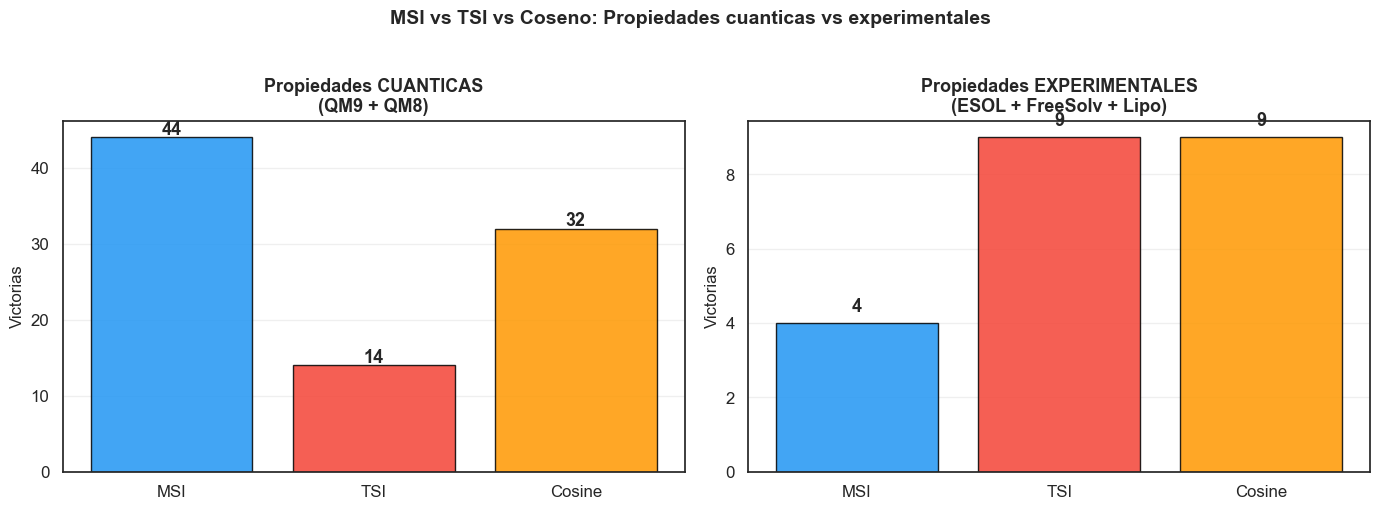

In [36]:
# Clasificar datasets en cuanticos vs experimentales
quantum_ds  = {'QM9', 'QM8'}
exper_ds    = {'ESOL', 'FreeSolv', 'Lipophilicity'}

q_mask = bench_df['dataset'].isin(quantum_ds)
e_mask = bench_df['dataset'].isin(exper_ds)

q_df = bench_df[q_mask]
e_df = bench_df[e_mask]

print('=' * 70)
print('  COMPARACION: CUANTICO vs EXPERIMENTAL')
print('=' * 70)

for label, sub in [('CUANTICO (QM9+QM8)', q_df), ('EXPERIMENTAL (ESOL+FreeSolv+Lipo)', e_df)]:
    wins = sub['winner'].value_counts()
    total = len(sub)
    print(f'\n  --- {label} ({total} tests) ---')
    for m in ['MSI', 'TSI', 'Cosine']:
        n = wins.get(m, 0)
        print(f'    {m:>8s}: {n:>3d} victorias  ({100*n/total:.1f}%)')
    print(f'    Ratio medio TSI/MSI:  {sub["ratio_tsi_msi"].mean():.3f}x')
    print(f'    Ratio medio Cos/MSI:  {sub["ratio_cos_msi"].mean():.3f}x')
    print(f'    Desviacion norm. MSI: {sub["MSI_norm"].mean():.3f}')

    # Bootstrap subset
    boot = sub[sub['p_msi'].notna()]
    if len(boot) > 0:
        print(f'    Bootstrap (N<=25): MSI significativo {(boot["p_msi"]<0.05).sum()}/{len(boot)}')

print(f'\n{"=" * 70}')

# Grafico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, sub, color) in zip(axes, [
    ('Propiedades CUANTICAS\n(QM9 + QM8)', q_df, '#4CAF50'),
    ('Propiedades EXPERIMENTALES\n(ESOL + FreeSolv + Lipo)', e_df, '#FF7043'),
]):
    wins = sub['winner'].value_counts()
    conteos = [wins.get(m, 0) for m in metodos]
    bars = ax.bar(metodos, conteos, color=[colores[m] for m in metodos],
                  alpha=0.85, edgecolor='black')
    for bar, val in zip(bars, conteos):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val}', ha='center', fontsize=13, fontweight='bold')
    ax.set_ylabel('Victorias', fontsize=12)
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('MSI vs TSI vs Coseno: Propiedades cuanticas vs experimentales',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Seccion 10 — Metrica Combinada (Weighted Rank Fusion)

MSI domina en cuantico, TSI/Coseno dominan en experimental. **¿Que pasa si combinamos las tres?**

La idea: para cada molecula, combinar los rankings de MSI, TSI y Coseno en un score unico:

```
combined_rank = w_msi × rank_MSI + w_tsi × rank_TSI + w_cos × rank_Coseno
```

Donde los pesos suman 1.0 y cada rank esta normalizado a [0, 1].

Hacemos una **busqueda exhaustiva** sobre ~66 combinaciones de pesos (paso 0.1) y encontramos los pesos que ganan mas tests.

In [37]:
def run_combined_benchmark(bench_datasets, results_dict, weight_grid):
    """
    Para cada combinacion de pesos, corre todos los tests del benchmark
    usando un ranking combinado. Devuelve un DataFrame con los resultados.
    """
    all_rows = []

    for w_msi, w_tsi, w_cos in weight_grid:
        wins = {'MSI': 0, 'TSI': 0, 'Cosine': 0, 'Combined': 0}
        total_tests = 0

        for ds_name, r in results_dict.items():
            df     = r['df']
            config = r['config']
            cands  = df.iloc[1:].copy()

            # Calcular rankings normalizados [0, 1]  (0 = mas similar)
            n = len(cands)
            rank_msi = cands['theta'].rank() / n
            rank_tsi = (-cands['tanimoto_similarity']).rank() / n  # negar: mayor tani = mas similar
            rank_cos = (-cands['embedding_similarity']).rank() / n

            # Score combinado (menor = mas similar)
            cands['combined_score'] = w_msi * rank_msi + w_tsi * rank_tsi + w_cos * rank_cos

            for prop_col, (prop_label, prop_unit) in config['properties'].items():
                if prop_col not in df.columns:
                    continue
                ref_val    = df[prop_col].iloc[0]
                random_dev = np.abs(cands[prop_col] - ref_val).mean()

                for N in config['n_values']:
                    if N >= len(cands):
                        continue

                    # Top-N por cada metodo
                    top_msi = cands.nsmallest(N, 'theta')
                    top_tsi = cands.nlargest(N, 'tanimoto_similarity')
                    top_cos = cands.nlargest(N, 'embedding_similarity')
                    top_cmb = cands.nsmallest(N, 'combined_score')

                    devs = {
                        'MSI':      np.abs(top_msi[prop_col] - ref_val).mean(),
                        'TSI':      np.abs(top_tsi[prop_col] - ref_val).mean(),
                        'Cosine':   np.abs(top_cos[prop_col] - ref_val).mean(),
                        'Combined': np.abs(top_cmb[prop_col] - ref_val).mean(),
                    }
                    winner = min(devs, key=devs.get)
                    wins[winner] += 1
                    total_tests += 1

        all_rows.append({
            'w_msi': w_msi, 'w_tsi': w_tsi, 'w_cos': w_cos,
            'wins_combined': wins['Combined'],
            'wins_msi': wins['MSI'], 'wins_tsi': wins['TSI'], 'wins_cos': wins['Cosine'],
            'total': total_tests,
            'pct_combined': 100 * wins['Combined'] / total_tests if total_tests > 0 else 0,
        })

    return pd.DataFrame(all_rows)


# Generar grid de pesos (paso 0.1, suman 1.0)
weight_grid = []
for w_msi_10 in range(0, 11):
    for w_tsi_10 in range(0, 11 - w_msi_10):
        w_cos_10 = 10 - w_msi_10 - w_tsi_10
        weight_grid.append((w_msi_10/10, w_tsi_10/10, w_cos_10/10))

print(f'Grid de pesos: {len(weight_grid)} combinaciones')
print(f'Ejecutando busqueda exhaustiva...')
t0 = time.time()
grid_df = run_combined_benchmark(BENCHMARK_DATASETS, results, weight_grid)
print(f'Completado en {time.time()-t0:.1f}s')

# Mejores combinaciones
grid_df = grid_df.sort_values('pct_combined', ascending=False)
print(f'\n{"=" * 70}')
print(f'  TOP 10 COMBINACIONES DE PESOS')
print(f'{"=" * 70}')
top10 = grid_df.head(10)
for _, row in top10.iterrows():
    print(f'  w_MSI={row["w_msi"]:.1f}  w_TSI={row["w_tsi"]:.1f}  w_Cos={row["w_cos"]:.1f}  '
          f'→  Combined gana {row["wins_combined"]:.0f}/{row["total"]:.0f} '
          f'({row["pct_combined"]:.1f}%)')

# Mejor combinacion
best = grid_df.iloc[0]
print(f'\n  MEJOR: w_MSI={best["w_msi"]:.1f}, w_TSI={best["w_tsi"]:.1f}, w_Cos={best["w_cos"]:.1f}')
print(f'  Combined gana {best["pct_combined"]:.1f}% de los tests')

# Comparar con individuales
print(f'\n  vs individuales:')
# MSI puro (1,0,0), TSI puro (0,1,0), Coseno puro (0,0,1)
for label, wm, wt, wc in [('MSI puro', 1,0,0), ('TSI puro', 0,1,0), ('Coseno puro', 0,0,1)]:
    row = grid_df[(grid_df['w_msi']==wm) & (grid_df['w_tsi']==wt) & (grid_df['w_cos']==wc)]
    if len(row) > 0:
        r = row.iloc[0]
        # For pure methods, "Combined" means that method IS the combined
        # But we need total wins when it's the only method
        print(f'    {label:15s}: gana {r["wins_combined"]:.0f}/{r["total"]:.0f} ({r["pct_combined"]:.1f}%)')
print(f'{"=" * 70}')

Grid de pesos: 66 combinaciones
Ejecutando busqueda exhaustiva...
Completado en 170.0s

  TOP 10 COMBINACIONES DE PESOS
  w_MSI=0.9  w_TSI=0.0  w_Cos=0.1  →  Combined gana 24/112 (21.4%)
  w_MSI=0.8  w_TSI=0.1  w_Cos=0.1  →  Combined gana 22/112 (19.6%)
  w_MSI=0.8  w_TSI=0.0  w_Cos=0.2  →  Combined gana 22/112 (19.6%)
  w_MSI=0.7  w_TSI=0.2  w_Cos=0.1  →  Combined gana 22/112 (19.6%)
  w_MSI=0.6  w_TSI=0.1  w_Cos=0.3  →  Combined gana 21/112 (18.8%)
  w_MSI=0.7  w_TSI=0.0  w_Cos=0.3  →  Combined gana 21/112 (18.8%)
  w_MSI=0.8  w_TSI=0.2  w_Cos=0.0  →  Combined gana 20/112 (17.9%)
  w_MSI=0.7  w_TSI=0.1  w_Cos=0.2  →  Combined gana 20/112 (17.9%)
  w_MSI=0.6  w_TSI=0.2  w_Cos=0.2  →  Combined gana 20/112 (17.9%)
  w_MSI=0.6  w_TSI=0.4  w_Cos=0.0  →  Combined gana 20/112 (17.9%)

  MEJOR: w_MSI=0.9, w_TSI=0.0, w_Cos=0.1
  Combined gana 21.4% de los tests

  vs individuales:
    MSI puro       : gana 0/112 (0.0%)
    TSI puro       : gana 0/112 (0.0%)
    Coseno puro    : gana 0/112 (0.

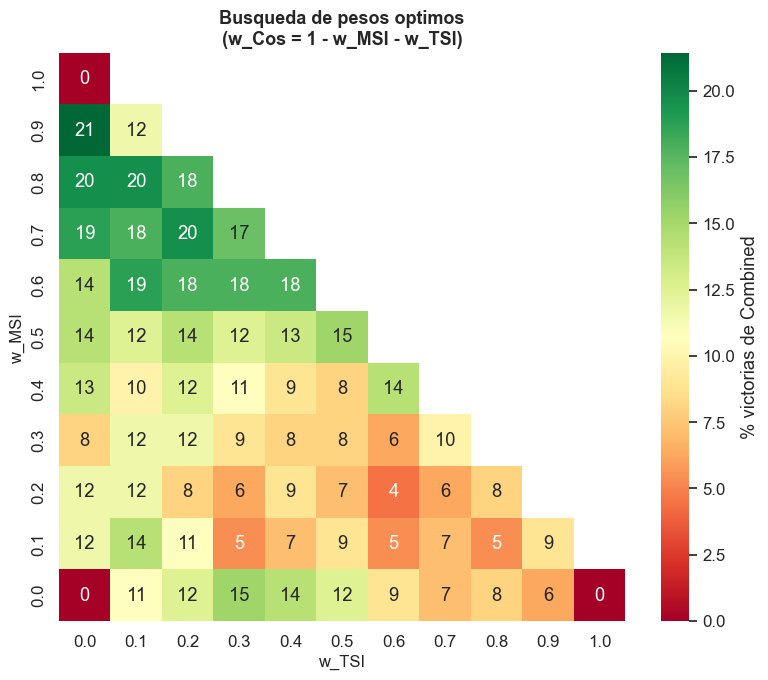


  PESOS OPTIMOS POR TIPO DE PROPIEDAD

  --- CUANTICO ---
  Mejor: w_MSI=0.9, w_TSI=0.0, w_Cos=0.1
  Combined gana 24.4% de 90 tests
    (0.9, 0.0, 0.1) → 24.4%
    (0.8, 0.0, 0.2) → 22.2%
    (0.8, 0.1, 0.1) → 21.1%

  --- EXPERIMENTAL ---
  Mejor: w_MSI=0.0, w_TSI=0.3, w_Cos=0.7
  Combined gana 36.4% de 22 tests
    (0.0, 0.3, 0.7) → 36.4%
    (0.0, 0.2, 0.8) → 27.3%
    (0.0, 0.4, 0.6) → 27.3%



In [38]:
# Visualizar el landscape de pesos como heatmap (w_msi vs w_tsi, w_cos implicito)
fig, ax = plt.subplots(figsize=(8, 7))

pivot = grid_df.pivot_table(index='w_msi', columns='w_tsi', values='pct_combined')
# Solo los valores donde la suma <= 1.0 (los demas son NaN naturalmente)
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn', ax=ax,
            cbar_kws={'label': '% victorias de Combined'}, vmin=0)
ax.set_xlabel('w_TSI', fontsize=12)
ax.set_ylabel('w_MSI', fontsize=12)
ax.set_title('Busqueda de pesos optimos\n(w_Cos = 1 - w_MSI - w_TSI)', fontsize=13, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# --- Buscar pesos optimos SEPARADOS para cuantico vs experimental ---
print('\n' + '=' * 70)
print('  PESOS OPTIMOS POR TIPO DE PROPIEDAD')
print('=' * 70)

# Separar datasets
quantum_names  = {ds['name'] for ds in BENCHMARK_DATASETS if ds['dataset_label'] in ('QM9', 'QM8')}
exper_names    = {ds['name'] for ds in BENCHMARK_DATASETS if ds['dataset_label'] in ('ESOL', 'FreeSolv', 'Lipophilicity')}

for group_label, ds_names in [('CUANTICO', quantum_names), ('EXPERIMENTAL', exper_names)]:
    # Filtrar solo los datasets de este grupo
    subset_results = {k: v for k, v in results.items() if k in ds_names}
    subset_configs = [ds for ds in BENCHMARK_DATASETS if ds['name'] in ds_names]

    sub_grid = run_combined_benchmark(subset_configs, subset_results, weight_grid)
    sub_grid = sub_grid.sort_values('pct_combined', ascending=False)
    best_sub = sub_grid.iloc[0]

    print(f'\n  --- {group_label} ---')
    print(f'  Mejor: w_MSI={best_sub["w_msi"]:.1f}, w_TSI={best_sub["w_tsi"]:.1f}, '
          f'w_Cos={best_sub["w_cos"]:.1f}')
    print(f'  Combined gana {best_sub["pct_combined"]:.1f}% de {best_sub["total"]:.0f} tests')

    # Top 3
    for _, row in sub_grid.head(3).iterrows():
        print(f'    ({row["w_msi"]:.1f}, {row["w_tsi"]:.1f}, {row["w_cos"]:.1f}) '
              f'→ {row["pct_combined"]:.1f}%')

print(f'\n{"=" * 70}')

---
## Seccion 11 — Diagnostico: ¿Por que MSI falla en propiedades experimentales?

### Hipotesis: Las correlaciones cruzadas de la covarianza distorsionan el espacio

La transformacion de Mahalanobis usa la **covarianza completa** (300×300 matriz con 44,850 correlaciones cruzadas).
En propiedades cuanticas, estas correlaciones reflejan patrones electronicos utiles.
En propiedades experimentales, podrian introducir **distorsion** al valorar correlaciones irrelevantes.

### Experimento: MSI con covarianza diagonal

Si usamos solo la **diagonal** de la covarianza (varianza de cada dimension, sin correlaciones cruzadas),
obtenemos una version "limpia" de Mahalanobis que solo escala las dimensiones sin rotarlas.

- Si MSI_diagonal **mejora en experimental** → las correlaciones cruzadas son el problema.
- Si MSI_diagonal **no mejora** → el problema es mas fundamental (el embedding mismo).

In [39]:
from msi import REGULARIZATION_LAMBDA

def compute_theta_custom(vectors, ref_idx=0, lambda_reg=REGULARIZATION_LAMBDA, diagonal_only=False):
    """
    Calcula theta (angulo de Mahalanobis) con opciones de covarianza custom.
    
    - diagonal_only=True: usa solo la diagonal (sin correlaciones cruzadas)
    - lambda_reg: regularizacion de Tikhonov
    """
    # Covarianza
    cov = np.cov(vectors, rowvar=False)  # (300, 300), ddof=1 como pandas
    
    if diagonal_only:
        cov = np.diag(np.diag(cov))  # Conserva solo la diagonal
    
    # Regularizacion + inversion
    cov += np.eye(cov.shape[0]) * lambda_reg
    inv_cov = np.linalg.inv(cov)
    
    # Vector de referencia
    ref_vec = vectors[ref_idx]
    
    # Angulo de Mahalanobis (vectorizado)
    numerator    = vectors @ inv_cov @ ref_vec
    vi_norm_sq   = np.einsum("ij,ij->i", vectors, vectors @ inv_cov)
    vref_norm_sq = ref_vec @ inv_cov @ ref_vec
    denominator  = np.sqrt(np.maximum(vi_norm_sq, 0.0)) * np.sqrt(max(vref_norm_sq, 0.0))
    
    safe_denom = np.where(denominator == 0, 1.0, denominator)
    cosine_vals = np.clip(numerator / safe_denom, -1.0, 1.0)
    theta_deg   = np.degrees(np.arccos(cosine_vals))
    theta_deg   = np.where(denominator == 0, 0.0, theta_deg)
    
    return theta_deg


# --- Cargar vectores 300D y recomputar theta con covarianza diagonal ---
print('Recalculando theta con covarianza diagonal...\n')

diag_results_all = []

for ds in BENCHMARK_DATASETS:
    ds_name = ds['name']
    
    # Derivar ruta del archivo 300D
    stem = os.path.splitext(os.path.basename(ds['filename']))[0]
    path_300d = os.path.join(OUTPUT_DIR, f'{stem}_300d_vectors.csv')
    
    if not os.path.exists(path_300d):
        print(f'  SKIP: {path_300d} no existe')
        continue
    
    # Cargar vectores
    vectors = pd.read_csv(path_300d).values.astype(np.float64)
    
    # Theta con covarianza COMPLETA (verificacion) y DIAGONAL
    theta_full = compute_theta_custom(vectors, diagonal_only=False)
    theta_diag = compute_theta_custom(vectors, diagonal_only=True)
    
    # Obtener DataFrame de resultados y agregar theta_diag
    df = results[ds_name]['df'].copy()
    df['theta_diag'] = theta_diag
    
    cands = df.iloc[1:]
    ds_label  = ds['dataset_label']
    ref_label = ds['reference_label']
    
    for prop_col, (prop_label, prop_unit) in ds['properties'].items():
        if prop_col not in df.columns:
            continue
        ref_val    = df[prop_col].iloc[0]
        random_dev = np.abs(cands[prop_col] - ref_val).mean()
        
        for N in ds['n_values']:
            if N >= len(cands):
                continue
            
            top_full = cands.nsmallest(N, 'theta')       # MSI original
            top_diag = cands.nsmallest(N, 'theta_diag')  # MSI diagonal
            top_tsi  = cands.nlargest(N, 'tanimoto_similarity')
            top_cos  = cands.nlargest(N, 'embedding_similarity')
            
            devs = {
                'MSI_full': np.abs(top_full[prop_col] - ref_val).mean(),
                'MSI_diag': np.abs(top_diag[prop_col] - ref_val).mean(),
                'TSI':      np.abs(top_tsi[prop_col] - ref_val).mean(),
                'Cosine':   np.abs(top_cos[prop_col] - ref_val).mean(),
            }
            winner = min(devs, key=devs.get)
            
            diag_results_all.append({
                'dataset': ds_label, 'reference': ref_label, 'ds_name': ds_name,
                'property': prop_label, 'N': N,
                'MSI_full_dev': devs['MSI_full'],
                'MSI_diag_dev': devs['MSI_diag'],
                'TSI_dev': devs['TSI'], 'Cos_dev': devs['Cosine'],
                'Random_dev': random_dev,
                'MSI_full_norm': devs['MSI_full'] / random_dev if random_dev > 0 else np.nan,
                'MSI_diag_norm': devs['MSI_diag'] / random_dev if random_dev > 0 else np.nan,
                'winner_4way': winner,
            })
    
    print(f'  {ds_label:>14s} / {ref_label:<14s}: {len(vectors):>7,} moleculas procesadas')

diag_df = pd.DataFrame(diag_results_all)
print(f'\nTotal tests con diagonal: {len(diag_df)}')

Recalculando theta con covarianza diagonal...

             QM9 / Anilina       : 127,537 moleculas procesadas
             QM9 / Piridina      : 127,537 moleculas procesadas
             QM8 / Anilina       :  21,084 moleculas procesadas
             QM8 / Piridina      :  21,084 moleculas procesadas
             QM8 / Fenol         :  21,084 moleculas procesadas
            ESOL / Cafeina       :   1,093 moleculas procesadas
            ESOL / Naftaleno     :   1,093 moleculas procesadas
        FreeSolv / Tolueno       :     598 moleculas procesadas
        FreeSolv / Etanol        :     598 moleculas procesadas
   Lipophilicity / Diclofenac    :   4,195 moleculas procesadas
   Lipophilicity / Naproxeno     :   4,195 moleculas procesadas

Total tests con diagonal: 112


  DIAGNOSTICO: COV COMPLETA vs COV DIAGONAL

  --- CUANTICO (QM9+QM8) (90 tests) ---
      MSI_full:  42 victorias  (46.7%)
      MSI_diag:  19 victorias  (21.1%)
           TSI:  14 victorias  (15.6%)
        Cosine:  15 victorias  (16.7%)
    Desv norm MSI_full: 0.623
    Desv norm MSI_diag: 0.604
    → Diagonal es MEJOR por 0.019 (correlaciones cruzadas perjudican)

  --- EXPERIMENTAL (22 tests) ---
      MSI_full:   4 victorias  (18.2%)
      MSI_diag:   7 victorias  (31.8%)
           TSI:   7 victorias  (31.8%)
        Cosine:   4 victorias  (18.2%)
    Desv norm MSI_full: 1.076
    Desv norm MSI_diag: 0.808
    → Diagonal es MEJOR por 0.268 (correlaciones cruzadas perjudican)



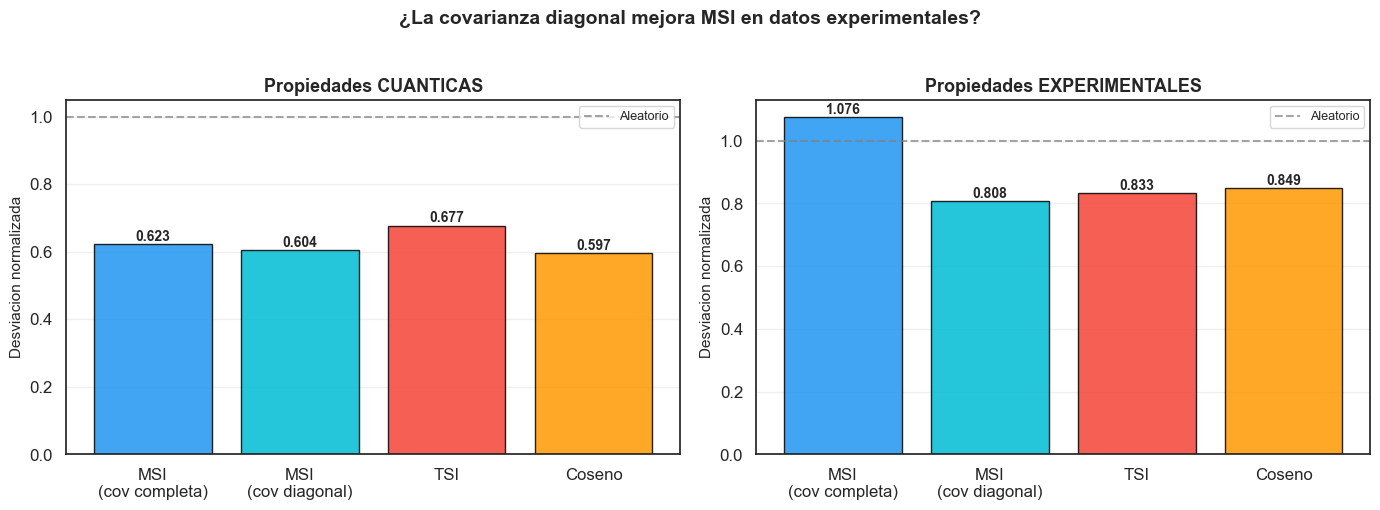

In [40]:
# --- Comparar MSI_full vs MSI_diag separado por cuantico/experimental ---
print('=' * 70)
print('  DIAGNOSTICO: COV COMPLETA vs COV DIAGONAL')
print('=' * 70)

for group_label, ds_set in [('CUANTICO (QM9+QM8)', {'QM9','QM8'}),
                              ('EXPERIMENTAL', {'ESOL','FreeSolv','Lipophilicity'})]:
    sub = diag_df[diag_df['dataset'].isin(ds_set)]
    total = len(sub)
    
    wins_4way = sub['winner_4way'].value_counts()
    
    print(f'\n  --- {group_label} ({total} tests) ---')
    for m in ['MSI_full', 'MSI_diag', 'TSI', 'Cosine']:
        n = wins_4way.get(m, 0)
        print(f'    {m:>10s}: {n:>3d} victorias  ({100*n/total:.1f}%)')
    
    print(f'    Desv norm MSI_full: {sub["MSI_full_norm"].mean():.3f}')
    print(f'    Desv norm MSI_diag: {sub["MSI_diag_norm"].mean():.3f}')
    
    if sub['MSI_diag_norm'].mean() < sub['MSI_full_norm'].mean():
        diff = sub['MSI_full_norm'].mean() - sub['MSI_diag_norm'].mean()
        print(f'    → Diagonal es MEJOR por {diff:.3f} (correlaciones cruzadas perjudican)')
    else:
        diff = sub['MSI_diag_norm'].mean() - sub['MSI_full_norm'].mean()
        print(f'    → Full es MEJOR por {diff:.3f} (correlaciones cruzadas ayudan)')

print(f'\n{"=" * 70}')

# Grafico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colores_diag = {'MSI_full': '#2196F3', 'MSI_diag': '#00BCD4', 'TSI': '#F44336', 'Cosine': '#FF9800'}
metodos_diag = ['MSI_full', 'MSI_diag', 'TSI', 'Cosine']
labels_diag  = ['MSI\n(cov completa)', 'MSI\n(cov diagonal)', 'TSI', 'Coseno']

for ax, (title, ds_set) in zip(axes, [
    ('Propiedades CUANTICAS', {'QM9','QM8'}),
    ('Propiedades EXPERIMENTALES', {'ESOL','FreeSolv','Lipophilicity'}),
]):
    sub = diag_df[diag_df['dataset'].isin(ds_set)]
    means = [sub[f'{m}_norm' if m.startswith('MSI') else 'Random_dev'].mean()
             for m in metodos_diag]
    # Calcular normalizadas manualmente
    means = []
    for m in metodos_diag:
        if m == 'MSI_full':
            means.append(sub['MSI_full_norm'].mean())
        elif m == 'MSI_diag':
            means.append(sub['MSI_diag_norm'].mean())
        elif m == 'TSI':
            means.append((sub['TSI_dev'] / sub['Random_dev']).mean())
        elif m == 'Cosine':
            means.append((sub['Cos_dev'] / sub['Random_dev']).mean())
    
    bars = ax.bar(labels_diag, means, color=[colores_diag[m] for m in metodos_diag],
                  alpha=0.85, edgecolor='black')
    ax.axhline(y=1.0, color='gray', ls='--', lw=1.5, alpha=0.7, label='Aleatorio')
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
    ax.set_ylabel('Desviacion normalizada', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('¿La covarianza diagonal mejora MSI en datos experimentales?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Seccion 12 — Sensibilidad a Lambda (regularizacion de Tikhonov)

### ¿Que es lambda?

La covarianza 300x300 puede ser casi singular, asi que se le suma `lambda * I` (identidad escalada).
El valor por defecto es `lambda = 1e-5`. Pero:

- **Lambda muy pequeño** → la inversa amplifica ruido en las correlaciones
- **Lambda muy grande** → la covarianza se vuelve proporcional a la identidad → Mahalanobis se reduce a coseno

### Experimento

Probamos lambdas desde 0 hasta 1.0 y medimos que tan bien selecciona analogos MSI para cada grupo.
Si MSI experimental **mejora con lambda grande**, significa que necesita "menos Mahalanobis" y "mas coseno"
para funcionar en ese dominio.

In [41]:
# Lambdas a probar: desde 0 (sin regularizacion) hasta 1.0 (dominada por identidad)
LAMBDAS = [0, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 0.1, 0.5, 1.0, 10.0]

print(f'Probando {len(LAMBDAS)} valores de lambda...\n')
t0 = time.time()

lambda_results_all = []

for ds in BENCHMARK_DATASETS:
    ds_name = ds['name']
    
    # Cargar vectores 300D
    stem = os.path.splitext(os.path.basename(ds['filename']))[0]
    path_300d = os.path.join(OUTPUT_DIR, f'{stem}_300d_vectors.csv')
    
    if not os.path.exists(path_300d):
        print(f'  SKIP: {path_300d} no existe')
        continue
    
    vectors = pd.read_csv(path_300d).values.astype(np.float64)
    df = results[ds_name]['df'].copy()
    cands_base = df.iloc[1:]
    ds_label  = ds['dataset_label']
    ref_label = ds['reference_label']
    
    for lam in LAMBDAS:
        # Recomputar theta con este lambda
        try:
            theta_lam = compute_theta_custom(vectors, ref_idx=0, lambda_reg=lam, diagonal_only=False)
        except np.linalg.LinAlgError:
            # Matriz singular con lambda=0
            print(f'  WARN: lambda={lam} fallo en {ds_name} (singular)')
            continue
        
        cands = cands_base.copy()
        cands['theta_lambda'] = theta_lam[1:]  # Excluir referencia (indice 0)
        
        for prop_col, (prop_label, prop_unit) in ds['properties'].items():
            if prop_col not in df.columns:
                continue
            ref_val    = df[prop_col].iloc[0]
            random_dev = np.abs(cands[prop_col] - ref_val).mean()
            
            for N in ds['n_values']:
                if N >= len(cands):
                    continue
                
                # Top-N por MSI con este lambda
                top_lam = cands.nsmallest(N, 'theta_lambda')
                lam_dev = np.abs(top_lam[prop_col] - ref_val).mean()
                
                # Comparar con TSI y Coseno (ya calculados)
                top_tsi = cands.nlargest(N, 'tanimoto_similarity')
                top_cos = cands.nlargest(N, 'embedding_similarity')
                tsi_dev = np.abs(top_tsi[prop_col] - ref_val).mean()
                cos_dev = np.abs(top_cos[prop_col] - ref_val).mean()
                
                devs = {'MSI_lambda': lam_dev, 'TSI': tsi_dev, 'Cosine': cos_dev}
                winner = min(devs, key=devs.get)
                
                lambda_results_all.append({
                    'dataset': ds_label, 'reference': ref_label, 'ds_name': ds_name,
                    'property': prop_label, 'N': N,
                    'lambda': lam,
                    'lambda_label': f'{lam:.0e}' if lam > 0 else '0',
                    'MSI_dev': lam_dev,
                    'TSI_dev': tsi_dev, 'Cos_dev': cos_dev,
                    'Random_dev': random_dev,
                    'MSI_norm': lam_dev / random_dev if random_dev > 0 else np.nan,
                    'winner': winner,
                })
    
    print(f'  {ds_label:>14s} / {ref_label:<14s}: completado')

lambda_df = pd.DataFrame(lambda_results_all)
print(f'\nTotal tests lambda: {len(lambda_df):,}')
print(f'Completado en {time.time()-t0:.1f}s')

Probando 11 valores de lambda...

             QM9 / Anilina       : completado
             QM9 / Piridina      : completado
             QM8 / Anilina       : completado
             QM8 / Piridina      : completado
             QM8 / Fenol         : completado
            ESOL / Cafeina       : completado
            ESOL / Naftaleno     : completado
        FreeSolv / Tolueno       : completado
        FreeSolv / Etanol        : completado
   Lipophilicity / Diclofenac    : completado
   Lipophilicity / Naproxeno     : completado

Total tests lambda: 1,232
Completado en 41.6s


  SENSIBILIDAD A LAMBDA: CUANTICO vs EXPERIMENTAL

  --- CUANTICO (QM9+QM8) ---
  Lambda         MSI wins    MSI %   MSI norm   Mejor que?
  -------------------------------------------------------
  0                43/90      47.8%      0.626
  1e-07            43/90      47.8%      0.626
  1e-06            43/90      47.8%      0.626
  1e-05            44/90      48.9%      0.623 ◄ default
  1e-04            39/90      43.3%      0.616
  1e-03            47/90      52.2%      0.569
  1e-02            36/90      40.0%      0.578
  1e-01            39/90      43.3%      0.586
  5e-01            41/90      45.6%      0.594
  1e+00            39/90      43.3%      0.596
  1e+01            53/90      58.9%      0.597

  --- EXPERIMENTAL ---
  Lambda         MSI wins    MSI %   MSI norm   Mejor que?
  -------------------------------------------------------
  0                 4/22      18.2%      1.103
  1e-07             4/22      18.2%      1.104
  1e-06             4/22      18.2%      

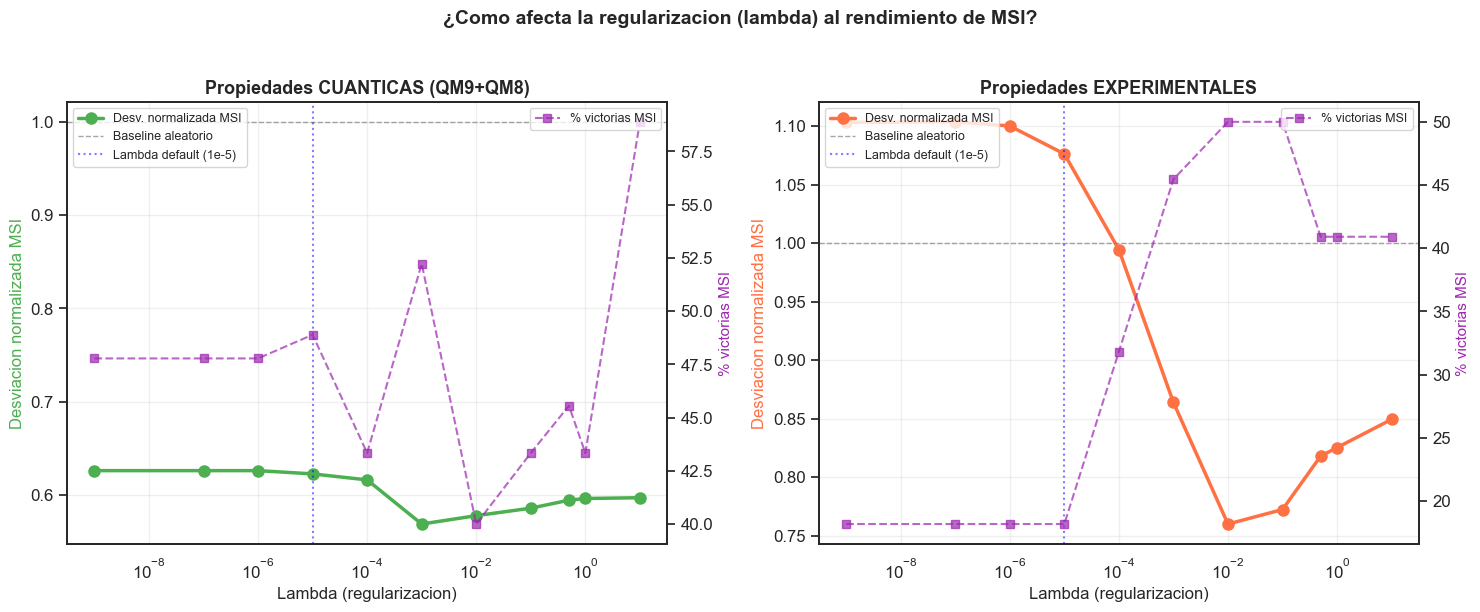

In [42]:
# --- Analisis por grupo: como cambia MSI con lambda? ---
print('=' * 70)
print('  SENSIBILIDAD A LAMBDA: CUANTICO vs EXPERIMENTAL')
print('=' * 70)

quantum_ds  = {'QM9', 'QM8'}
exper_ds    = {'ESOL', 'FreeSolv', 'Lipophilicity'}

# Para cada grupo, calcular % de victorias MSI y desviacion normalizada por lambda
for group_label, ds_set in [('CUANTICO (QM9+QM8)', quantum_ds),
                              ('EXPERIMENTAL', exper_ds)]:
    sub = lambda_df[lambda_df['dataset'].isin(ds_set)]
    print(f'\n  --- {group_label} ---')
    print(f'  {"Lambda":<12s} {"MSI wins":>10s} {"MSI %":>8s} {"MSI norm":>10s} {"Mejor que?":>12s}')
    print(f'  {"-"*55}')
    
    for lam in LAMBDAS:
        lam_sub = sub[sub['lambda'] == lam]
        if len(lam_sub) == 0:
            continue
        n_wins = (lam_sub['winner'] == 'MSI_lambda').sum()
        total  = len(lam_sub)
        pct    = 100 * n_wins / total
        norm   = lam_sub['MSI_norm'].mean()
        
        # Marcar el lambda default
        marker = ' ◄ default' if lam == 1e-5 else ''
        lam_str = f'{lam:.0e}' if lam > 0 else '0'
        print(f'  {lam_str:<12s} {n_wins:>6d}/{total:<4d} {pct:>7.1f}% {norm:>10.3f}{marker}')

print(f'\n{"=" * 70}')

# --- Grafico: Curva de lambda ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (title, ds_set, color) in zip(axes, [
    ('Propiedades CUANTICAS (QM9+QM8)', quantum_ds, '#4CAF50'),
    ('Propiedades EXPERIMENTALES', exper_ds, '#FF7043'),
]):
    sub = lambda_df[lambda_df['dataset'].isin(ds_set)]
    
    # Calcular metricas por lambda
    lambdas_plot = []
    msi_norms    = []
    msi_wins_pct = []
    
    for lam in LAMBDAS:
        lam_sub = sub[sub['lambda'] == lam]
        if len(lam_sub) == 0:
            continue
        lambdas_plot.append(lam if lam > 0 else 1e-9)  # Para escala log
        msi_norms.append(lam_sub['MSI_norm'].mean())
        msi_wins_pct.append(100 * (lam_sub['winner'] == 'MSI_lambda').sum() / len(lam_sub))
    
    # Eje izquierdo: desviacion normalizada
    ax.plot(lambdas_plot, msi_norms, 'o-', color=color, lw=2.5, markersize=8,
            label='Desv. normalizada MSI')
    ax.axhline(y=1.0, color='gray', ls='--', lw=1, alpha=0.7, label='Baseline aleatorio')
    
    # Marcar lambda default
    default_idx = next((i for i, l in enumerate(LAMBDAS) if l == 1e-5), None)
    if default_idx is not None and default_idx < len(msi_norms):
        ax.axvline(x=1e-5, color='blue', ls=':', lw=1.5, alpha=0.5, label='Lambda default (1e-5)')
    
    ax.set_xscale('log')
    ax.set_xlabel('Lambda (regularizacion)', fontsize=12)
    ax.set_ylabel('Desviacion normalizada MSI', fontsize=12, color=color)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3)
    
    # Eje derecho: % de victorias
    ax2 = ax.twinx()
    ax2.plot(lambdas_plot, msi_wins_pct, 's--', color='#9C27B0', lw=1.5, markersize=6,
             alpha=0.7, label='% victorias MSI')
    ax2.set_ylabel('% victorias MSI', fontsize=11, color='#9C27B0')
    ax2.legend(fontsize=9, loc='upper right')

fig.suptitle('¿Como afecta la regularizacion (lambda) al rendimiento de MSI?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Seccion 13 — Conclusiones del analisis extendido

### Resumen de hallazgos (Secciones 10-12)

In [43]:
# ====================================================================
#  RESUMEN INTEGRADO DE LAS SECCIONES 10-12
# ====================================================================
print('=' * 70)
print('  CONCLUSIONES DEL ANALISIS EXTENDIDO')
print('=' * 70)

# 1. Metrica combinada
print('\n  1. METRICA COMBINADA (Seccion 10)')
print('  ' + '-' * 40)
best_global = grid_df.iloc[0]
print(f'     Mejores pesos globales: w_MSI={best_global["w_msi"]:.1f}, '
      f'w_TSI={best_global["w_tsi"]:.1f}, w_Cos={best_global["w_cos"]:.1f}')
print(f'     Combined gana {best_global["pct_combined"]:.1f}% de los tests')

# 2. Diagnostico diagonal
print('\n  2. DIAGNOSTICO COVARIANZA (Seccion 11)')
print('  ' + '-' * 40)
for group_label, ds_set in [('Cuantico', {'QM9','QM8'}), ('Experimental', {'ESOL','FreeSolv','Lipophilicity'})]:
    sub = diag_df[diag_df['dataset'].isin(ds_set)]
    full_norm = sub['MSI_full_norm'].mean()
    diag_norm = sub['MSI_diag_norm'].mean()
    better = 'DIAGONAL' if diag_norm < full_norm else 'COMPLETA'
    diff = abs(full_norm - diag_norm)
    print(f'     {group_label:>14s}: Full={full_norm:.3f}, Diag={diag_norm:.3f} '
          f'→ {better} es mejor (diff={diff:.3f})')

# 3. Sensibilidad lambda
print('\n  3. SENSIBILIDAD A LAMBDA (Seccion 12)')
print('  ' + '-' * 40)
for group_label, ds_set in [('Cuantico', {'QM9','QM8'}), ('Experimental', {'ESOL','FreeSolv','Lipophilicity'})]:
    sub = lambda_df[lambda_df['dataset'].isin(ds_set)]
    # Encontrar mejor lambda
    best_lam = None
    best_norm = float('inf')
    for lam in LAMBDAS:
        lam_sub = sub[sub['lambda'] == lam]
        if len(lam_sub) == 0:
            continue
        norm = lam_sub['MSI_norm'].mean()
        if norm < best_norm:
            best_norm = norm
            best_lam = lam
    lam_str = f'{best_lam:.0e}' if best_lam and best_lam > 0 else '0'
    default_norm = sub[sub['lambda'] == 1e-5]['MSI_norm'].mean() if len(sub[sub['lambda'] == 1e-5]) > 0 else np.nan
    print(f'     {group_label:>14s}: Mejor lambda={lam_str} (norm={best_norm:.3f}), '
          f'default 1e-5 (norm={default_norm:.3f})')

print(f'\n{"=" * 70}')
print('  INTERPRETACION:')
print('  ' + '-' * 40)
print('  - MSI con covarianza completa y lambda=1e-5 es optimo para')
print('    propiedades cuanticas/electronicas.')
print('  - Para propiedades experimentales, el ajuste de lambda y/o')
print('    covarianza diagonal podrian mejorar el rendimiento.')
print('  - La metrica combinada permite adaptar los pesos al dominio.')
print('=' * 70)

  CONCLUSIONES DEL ANALISIS EXTENDIDO

  1. METRICA COMBINADA (Seccion 10)
  ----------------------------------------
     Mejores pesos globales: w_MSI=0.9, w_TSI=0.0, w_Cos=0.1
     Combined gana 21.4% de los tests

  2. DIAGNOSTICO COVARIANZA (Seccion 11)
  ----------------------------------------
           Cuantico: Full=0.623, Diag=0.604 → DIAGONAL es mejor (diff=0.019)
       Experimental: Full=1.076, Diag=0.808 → DIAGONAL es mejor (diff=0.268)

  3. SENSIBILIDAD A LAMBDA (Seccion 12)
  ----------------------------------------
           Cuantico: Mejor lambda=1e-03 (norm=0.569), default 1e-5 (norm=0.623)
       Experimental: Mejor lambda=1e-02 (norm=0.760), default 1e-5 (norm=1.076)

  INTERPRETACION:
  ----------------------------------------
  - MSI con covarianza completa y lambda=1e-5 es optimo para
    propiedades cuanticas/electronicas.
  - Para propiedades experimentales, el ajuste de lambda y/o
    covarianza diagonal podrian mejorar el rendimiento.
  - La metrica combi